# Richter's Predictor: Modeling Earthquake Damage
## Nepal Earthquake — DrivenData Competition

### Problem Statement

In April 2015, a 7.8-magnitude earthquake struck Nepal near Gorkha, causing widespread destruction.
This project uses survey data collected by **Kathmandu Living Labs** and the **Central Bureau of
Statistics** to predict the level of structural damage sustained by individual buildings.

**Target variable:** `damage_grade` — an ordinal variable with three levels:
- **1** → Low damage
- **2** → Medium damage
- **3** → Near-complete destruction

**Why this matters:** Accurate damage prediction models can help disaster-response teams prioritise
resources, guide rebuilding policy, and inform future construction standards in seismically active
regions.

---

## Notebook Structure

| Phase | Description |
|-------|-------------|
| **1 — EDA** | Explore the target and all predictor distributions; identify key patterns |
| **2 — Preprocessing + Baseline** | Encode features, split data, train a simple baseline model |
| **3 — Feature Engineering** | Create new features motivated by EDA findings |
| **4 — Model Comparison + Tuning** | Compare multiple algorithms; tune the best one |
| **5 — Interpretability** | Use SHAP to explain what the final model learned |

This notebook is **Phase 1: Exploratory Data Analysis**.


## 0. Setup

Import all libraries and configure plot aesthetics used throughout this notebook.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

# ── Output directories ────────────────────────────────────────────────────────
phase1_output_dir = Path('./images/phase 1')
phase2_output_dir = Path('./images/phase 2')
phase3_output_dir = Path('./images/phase 3')
phase4_output_dir = Path('./images/phase 4')
phase5_output_dir = Path('./images/phase 5')

# Custom ordered palette for damage grades (green → amber → red)
DAMAGE_PALETTE = {1: '#4CAF50', 2: '#FF9800', 3: '#E53935'}
DAMAGE_LABELS  = {1: 'Grade 1 — Low', 2: 'Grade 2 — Medium', 3: 'Grade 3 — Destruction'}

print("Libraries loaded successfully.")
print(f"Pandas  : {pd.__version__}")
print(f"NumPy   : {np.__version__}")
print(f"Seaborn : {sns.__version__}")


Libraries loaded successfully.
Pandas  : 2.3.3
NumPy   : 1.26.4
Seaborn : 0.13.2


## 1. Data Loading

The competition provides three CSV files:
- `train_values.csv` — feature matrix for training buildings
- `train_labels.csv` — target column (`damage_grade`) matched by `building_id`
- `test_values.csv`  — feature matrix for the held-out test set (no labels)

We merge features and labels on `building_id` to form our working training dataframe.


In [11]:
# ── Load raw files ────────────────────────────────────────────────────────────
train_values = pd.read_csv('./data/train_values.csv')
train_labels = pd.read_csv('./data/train_labels.csv')
test_values  = pd.read_csv('./data/test_values.csv')

# ── Merge features + labels into one training dataframe ───────────────────────
df = train_values.merge(train_labels, on='building_id')

print(f"Training set : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Test set     : {test_values.shape[0]:,} rows × {test_values.shape[1]} columns")
df.head(3)


Training set : 260,601 rows × 40 columns
Test set     : 86,868 rows × 39 columns


,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3


## 2. Data Quality Check

Before any analysis we verify the dataset's integrity: missing values, data types, and basic shape. Knowing there are no gaps is itself a useful finding it means we won't need imputation strategies, which simplifies our preprocessing pipeline. However, since the dataset is provided from Driven Data, this is mostly a sanity check.


In [12]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df.isnull().sum()
print("=== Missing values ===")
if missing.sum() == 0:
    print("  No missing values found in any column. ✓")
else:
    print(missing[missing > 0])

# ── Column types ─────────────────────────────────────────────────────────────
print(f"\n=== Column types ===")
type_counts = df.dtypes.astype(str).value_counts()
for t, n in type_counts.items():
    print(f"  {t:12s}: {n} columns")

# ── Identify feature groups ───────────────────────────────────────────────────
geo_cols        = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
numeric_cols    = ['count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'count_families']
categorical_cols= ['land_surface_condition', 'foundation_type', 'roof_type',
                   'ground_floor_type', 'other_floor_type', 'position',
                   'plan_configuration', 'legal_ownership_status']
superstructure_cols = [c for c in df.columns if c.startswith('has_superstructure_')]
secondary_use_cols  = [c for c in df.columns if c.startswith('has_secondary_use_')]

print(f"\n=== Feature groups ===")
print(f"  Geographic IDs       : {len(geo_cols)} columns")
print(f"  Numeric building     : {len(numeric_cols)} columns")
print(f"  Categorical building : {len(categorical_cols)} columns")
print(f"  Superstructure flags : {len(superstructure_cols)} columns")
print(f"  Secondary-use flags  : {len(secondary_use_cols)} columns")


=== Missing values ===
  No missing values found in any column. ✓

=== Column types ===
  int64       : 32 columns
  object      : 8 columns

=== Feature groups ===
  Geographic IDs       : 3 columns
  Numeric building     : 5 columns
  Categorical building : 8 columns
  Superstructure flags : 11 columns
  Secondary-use flags  : 10 columns


## 3. Target Variable — `damage_grade`

Understanding the distribution of our target is the most critical first step. If the classes are imbalanced, plain accuracy will be a misleading metric. A model that always predicts the majority class would score high without being useful.

**Finding:** The imbalanced target variable distribution combined with the potential real-world harm an incorrect prediction could have, Macro-F1 would make sense as a primary metric, as each class's F1 score would be weighted equally. However, Data Driven has decided to use Micro-F1 as the primary metric which will potentially mask poor preformance on predicting damage grades one and three.


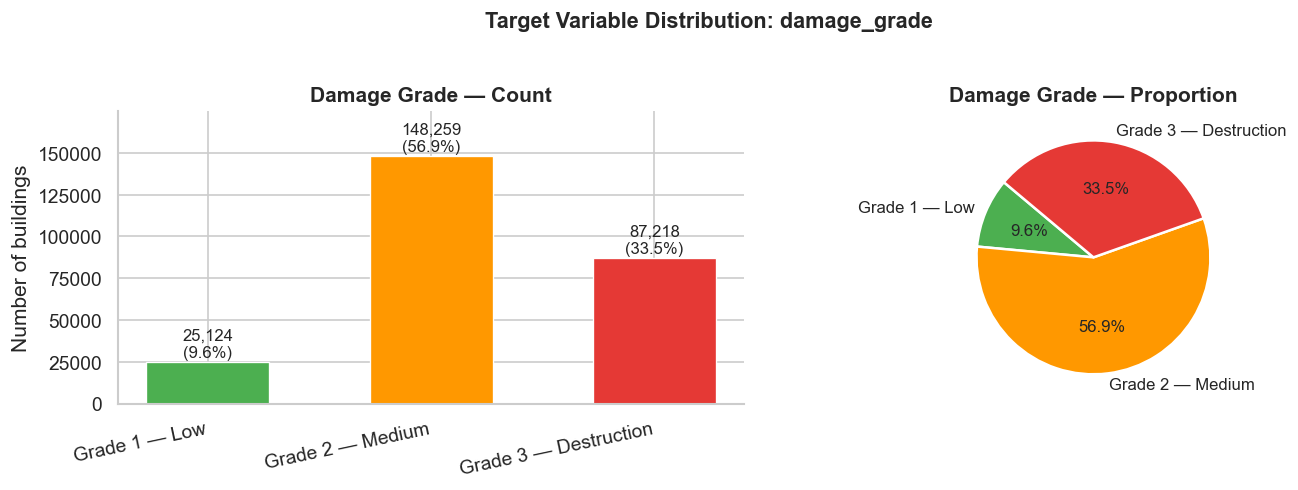

Key findings:
Grade 2 dominates at 56.891 while,
Grade 1 is the minority at 9.641 and
Grade 3 sits in the middle accounting for 33.468% of buildings.
Target variable imbalance supports our decision to use the Micro-averaged F1 score as our primary evaluation metric.



In [ ]:
# ── Compute counts and percentages ────────────────────────────────────────────
target_counts = df['damage_grade'].value_counts().sort_index()
target_pct    = df['damage_grade'].value_counts(normalize=True).sort_index() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: count bar chart
bars = axes[0].bar(
    [DAMAGE_LABELS[g] for g in target_counts.index],
    target_counts.values,
    color=[DAMAGE_PALETTE[g] for g in target_counts.index],
    edgecolor='white', linewidth=0.8, width=0.55
)
# Annotate each bar with count + percentage
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 800,
        f'{count:,}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
axes[0].set_title('Damage Grade — Count', fontweight='bold')
axes[0].set_ylabel('Number of buildings')
axes[0].set_ylim(0, target_counts.max() * 1.18)
axes[0].set_xticklabels([DAMAGE_LABELS[g] for g in target_counts.index], rotation=12, ha='right')

# Right: pie chart
axes[1].pie(
    target_counts.values,
    labels=[DAMAGE_LABELS[g] for g in target_counts.index],
    colors=[DAMAGE_PALETTE[g] for g in target_counts.index],
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops={'fontsize': 10}
)
axes[1].set_title('Damage Grade — Proportion', fontweight='bold')

fig.suptitle('Target Variable Distribution: damage_grade', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(phase1_output_dir / 'fig1_target_distribution.png', bbox_inches='tight')
plt.show()

print(f"""Key findings:
Grade 2 dominates at {target_pct[2]:.3f} while,
Grade 1 is the minority at {target_pct[1]:.3f} and
Grade 3 sits in the middle accounting for {target_pct[3]:.3f}% of buildings.
Target variable imbalance supports our decision to use the Micro-averaged F1 score as our primary evaluation metric.
""")


## 4. Continuous Feature Exploration

This dataset contains a mix of numeric values:
- continuous building measurements like `age`, `count_floors_pre_eq`, `area_percentage`, `height_percentage`, and `count_families`
- binary structural and secondary-use indicators such as `has_superstructure_rc_engineered`
- geographic IDs and metadata such as `geo_level_1_id`

Here we explore the numeric continuous feature space more generally by creating a distribution of continuous metrics by damage grade and find the mediaun values for each metric. Visualizing the data in this manner will allow us to determine if data normalization/processing will be nescessary as well as the correlation each feature has with damage grade.


FileNotFoundError: [Errno 2] No such file or directory: './images/phase 1/../images/phase 1/fig2_numeric_distributions.png'

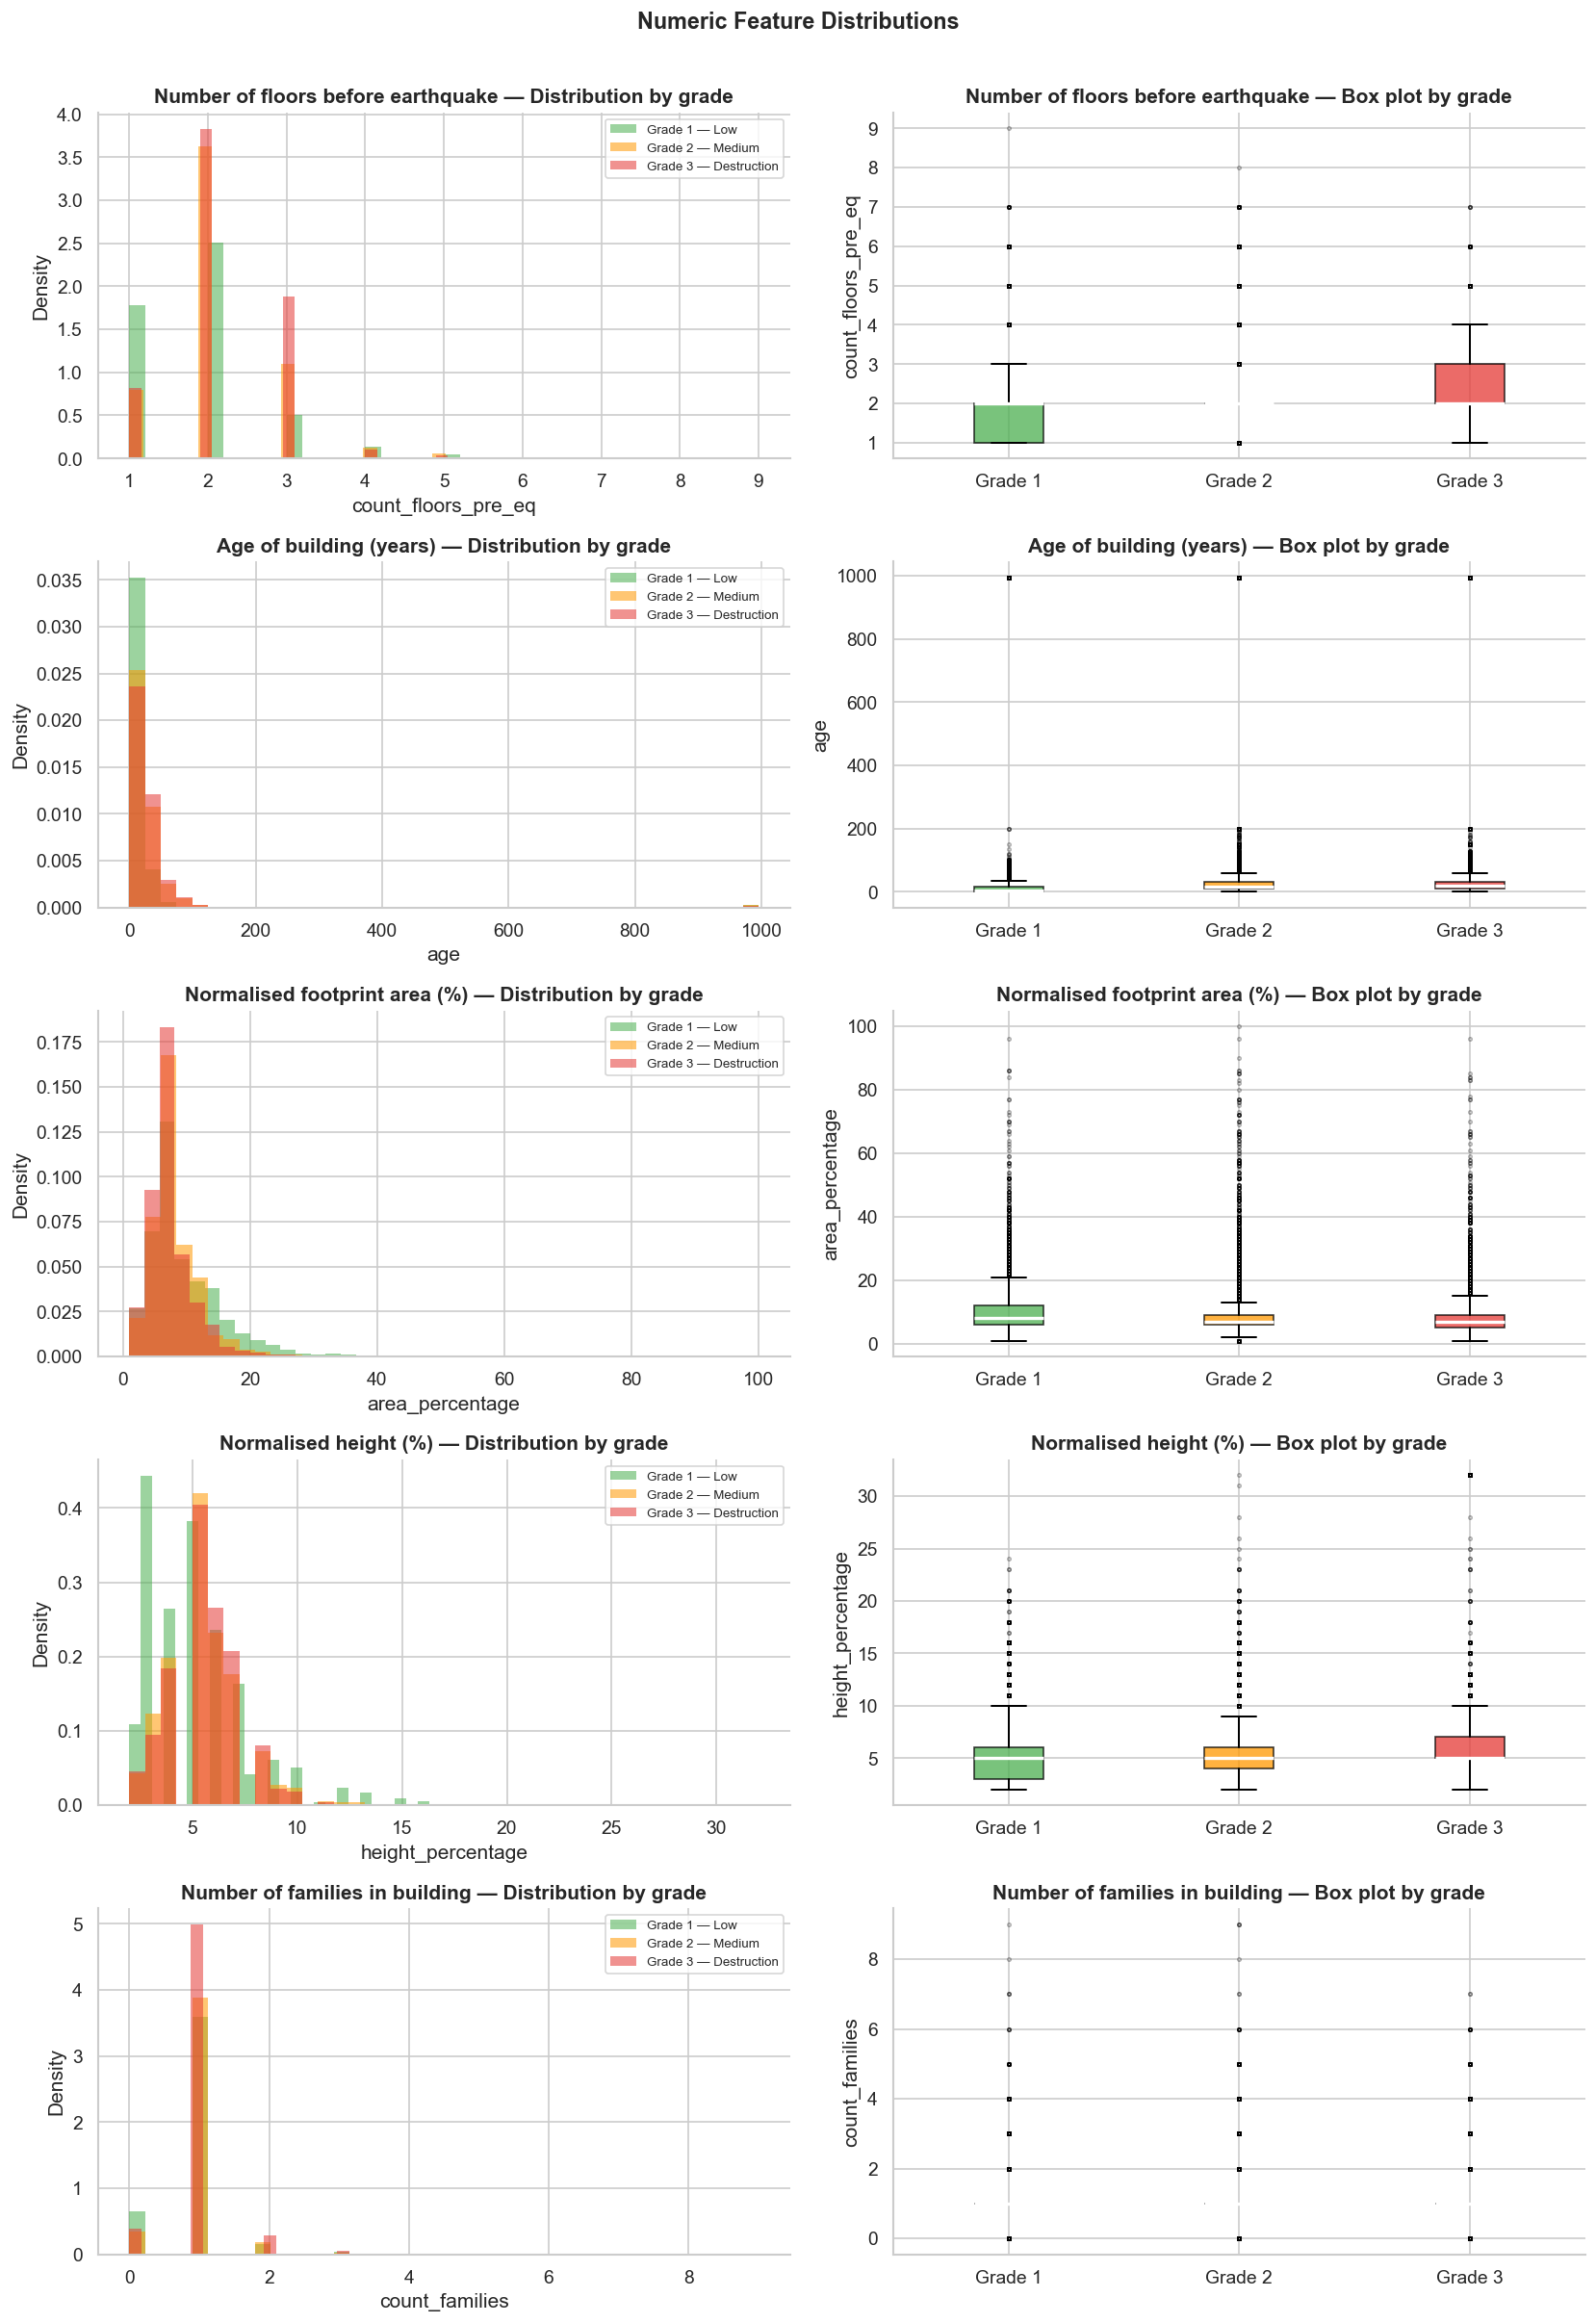

In [ ]:
numeric_meta = {
    'count_floors_pre_eq': 'Number of floors before earthquake',
    'age'                : 'Age of building (years)',
    'area_percentage'    : 'Normalised footprint area (%)',
    'height_percentage'  : 'Normalised height (%)',
    'count_families'     : 'Number of families in building',
}

fig, axes = plt.subplots(len(numeric_meta), 2, figsize=(14, 4 * len(numeric_meta)))

for row, (col, label) in enumerate(numeric_meta.items()):
    data = df[col]

    # ── Left: histogram coloured by damage grade ──────────────────────────────
    ax_hist = axes[row, 0]
    for grade in [1, 2, 3]:
        subset = df.loc[df['damage_grade'] == grade, col]
        ax_hist.hist(
            subset, bins=40, alpha=0.55,
            color=DAMAGE_PALETTE[grade], label=DAMAGE_LABELS[grade],
            density=True, edgecolor='none'
        )
    ax_hist.set_title(f'{label} — Distribution by grade', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Density')
    ax_hist.legend(fontsize=8)

    # ── Right: box plot by damage grade ───────────────────────────────────────
    ax_box = axes[row, 1]
    grade_data = [df.loc[df['damage_grade'] == g, col].values for g in [1, 2, 3]]
    bp = ax_box.boxplot(
        grade_data,
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3)
    )
    for patch, grade in zip(bp['boxes'], [1, 2, 3]):
        patch.set_facecolor(DAMAGE_PALETTE[grade])
        patch.set_alpha(0.75)
    ax_box.set_xticks([1, 2, 3])
    ax_box.set_xticklabels([f'Grade {g}' for g in [1, 2, 3]])
    ax_box.set_title(f'{label} — Box plot by grade', fontweight='bold')
    ax_box.set_ylabel(col)

fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(phase1_output_dir / 'fig2_numeric_distributions.png', bbox_inches='tight')
plt.show()

# ── Summary statistics per grade ──────────────────────────────────────────────
print("=== Median values by damage grade ===")
print(df.groupby('damage_grade')[list(numeric_meta.keys())].median().round(2).to_string())


### Observations on numeric features

| Feature | Pattern |
|---------|---------|
| `age` | Older buildings skew toward higher damage grades — intuitive, as older structures predate modern seismic codes |
| `count_floors_pre_eq` | Taller buildings show slightly higher damage; multi-storey structures are more vulnerable |
| `area_percentage` | Smaller footprints correlate with more destruction. Likely relationship with the number of floors, more floors in smaller area = less stability |
| `height_percentage` | Higher normalised height is associated with greater damage |
| `count_families` | Relatively uniform across grades; less likely to be a strong predictor on its own |


## 5. Categorical Feature Distributions

The dataset contains eight categorical columns encoded as single letters. Their meanings
are not fully documented by the competition, but the distributions and damage-grade
breakdowns can still reveal which categories carry the most predictive signal.

For each feature we plot a **stacked proportional bar chart** — this makes it easy to
compare the damage-grade mix across categories of very different sizes.


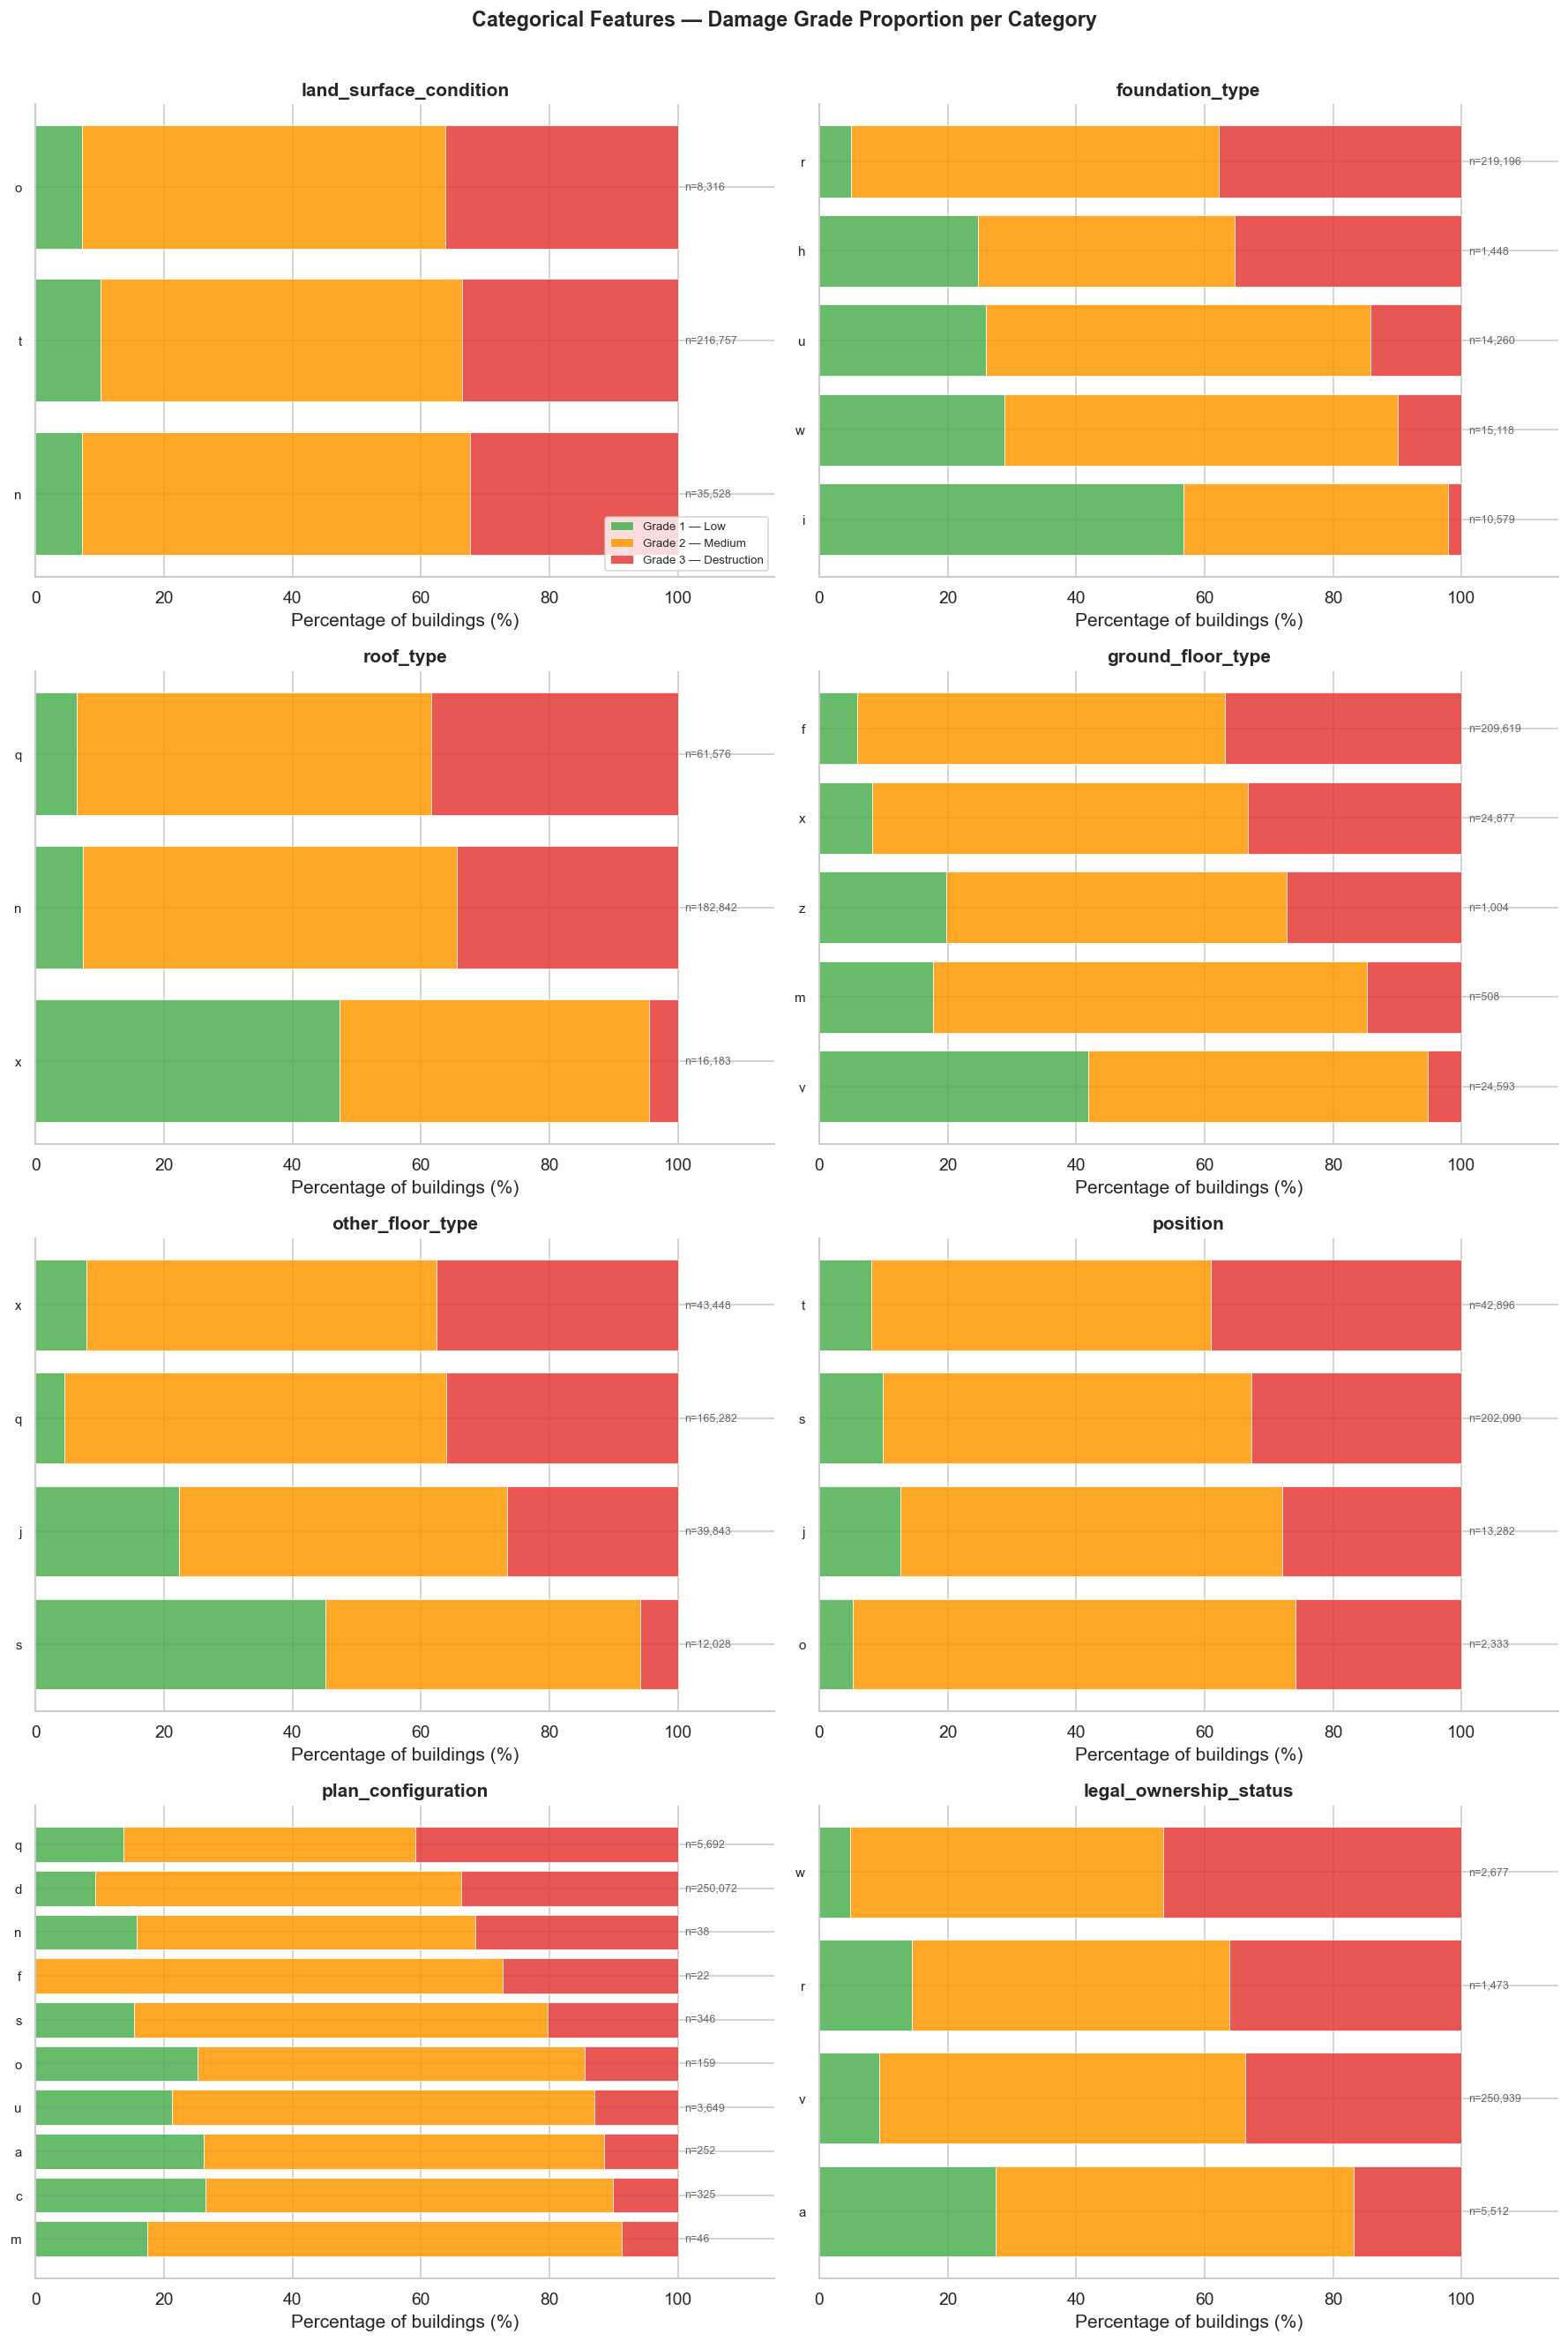

In [ ]:
# ── Stacked proportion bars for each categorical column ───────────────────────
fig, axes = plt.subplots(4, 2, figsize=(15, 22))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]

    # Count damage grade per category, normalise to proportions
    ct = (df.groupby([col, 'damage_grade'])
            .size()
            .unstack(fill_value=0))
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # Sort categories by Grade-3 proportion (most damaged first)
    ct_pct = ct_pct.sort_values(3, ascending=True)

    # Build stacked bars
    bottom = np.zeros(len(ct_pct))
    for grade in [1, 2, 3]:
        vals = ct_pct[grade].values
        bars = ax.barh(
            range(len(ct_pct)), vals, left=bottom,
            color=DAMAGE_PALETTE[grade], label=DAMAGE_LABELS[grade],
            alpha=0.85, edgecolor='white', linewidth=0.5
        )
        bottom += vals

    # Annotate with raw count per category
    raw_counts = ct.sum(axis=1).loc[ct_pct.index]
    for i, (cat, cnt) in enumerate(raw_counts.items()):
        ax.text(101, i, f'n={cnt:,}', va='center', fontsize=7.5,
                color='dimgray')

    ax.set_yticks(range(len(ct_pct)))
    ax.set_yticklabels(ct_pct.index.tolist(), fontsize=9)
    ax.set_xlabel('Percentage of buildings (%)')
    ax.set_xlim(0, 115)
    ax.set_title(col, fontweight='bold')
    if idx == 0:
        ax.legend(loc='lower right', fontsize=8)

# Hide unused subplot if any
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Features — Damage Grade Proportion per Category',
             fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig4_categorical_distributions.png', bbox_inches='tight')
plt.show()


### Observations on categorical features

| Feature | Key finding |
|---------|-------------|
| `foundation_type` | Clear separation: type `h` shows a very different damage profile from type `r`; foundation type is likely a strong predictor |
| `roof_type` | Type `n` (the dominant category) shows higher Grade-3 proportion than type `x` |
| `ground_floor_type` | Type `v` shows noticeably less damage than `f`; floor construction matters |
| `land_surface_condition` | Buildings on steep terrain (`o`) show higher severe-damage rates than flat (`t`) |
| `position` | Standalone buildings (`s`) show different profiles from corner (`j`) or attached (`t`) |
| `plan_configuration` | Heavily skewed — category `d` holds ~96% of buildings; most other categories are rare |
| `legal_ownership_status` | Dominated by `v` (96%); limited predictive power expected |
| `other_floor_type` | Predominantly `q` is skewed towards grade 2 & 3, minority category `s` on the other hand, is skewed towards grade 1 | 

> **Encoding decision:** All categorical features will be **ordinal-encoded** in Phase 2,
> assigning each letter a consistent integer. Since tree-based models don't assume ordinality,
> this is equivalent to one-hot encoding without the dimensionality cost.


## 6. Superstructure Material Flags

Buildings can be constructed from multiple materials simultaneously (each flag is 0/1).
We examine two things:
1. **Prevalence** — how common is each material in the dataset?
2. **Damage association** — is the material linked to higher or lower damage grades?

The comparison of mean damage grade between flag=0 and flag=1 gives a simple but
interpretable signal of each material's relationship to destruction.


           Material  Count (flag=1)  % of buildings  Mean damage (flag=1)  Mean damage (flag=0)  Delta
      Rc Engineered            4133             1.6                 1.376                 2.252 -0.877
Cement Mortar Brick           19615             7.5                 1.693                 2.283 -0.589
  Rc Non Engineered           11099             4.3                 1.780                 2.259 -0.479
Cement Mortar Stone            4752             1.8                 1.968                 2.243 -0.276
              Other            3905             1.5                 2.088                 2.241 -0.152
             Bamboo           22154             8.5                 2.112                 2.250 -0.138
             Timber           66450            25.5                 2.165                 2.263 -0.098
   Mud Mortar Brick           17761             6.8                 2.271                 2.236  0.035
          Adobe Mud           23101             8.9                 2.347

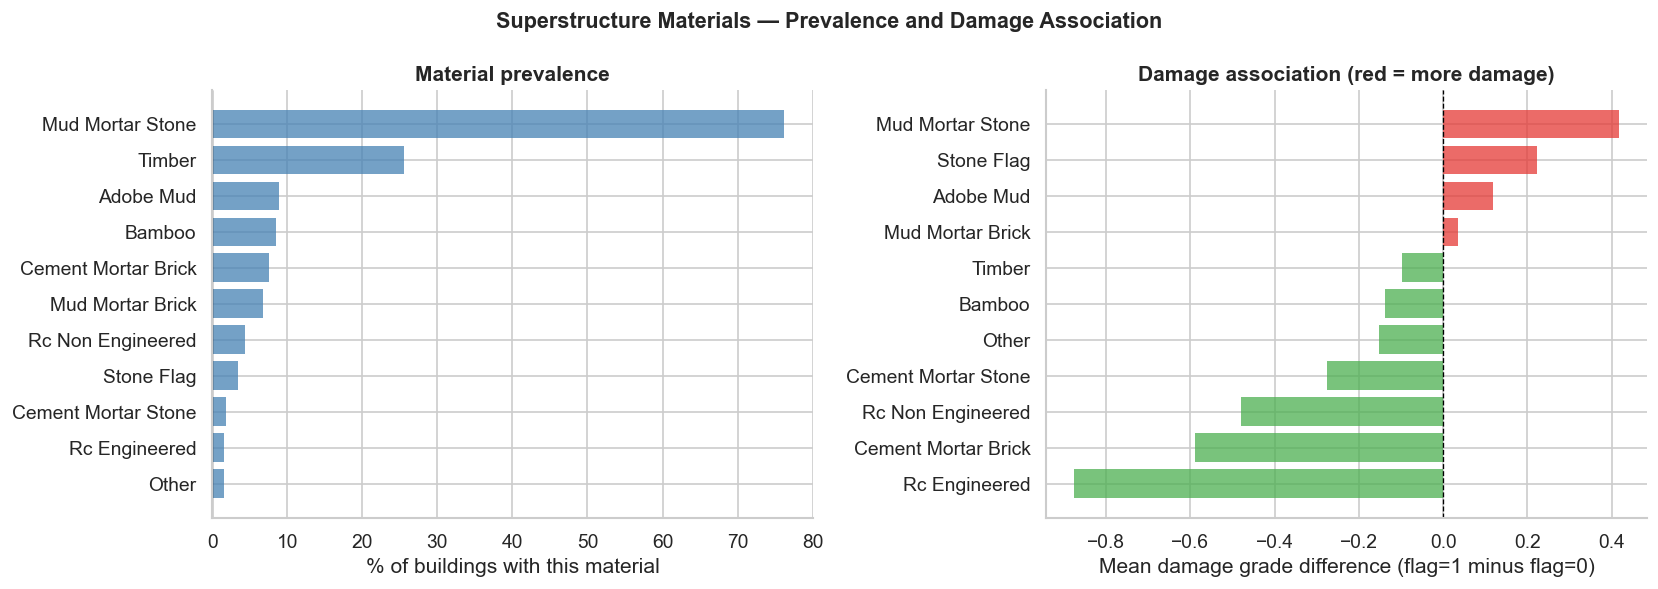

In [ ]:
# ── Compute prevalence and mean damage grade for flag=1 vs flag=0 ─────────────
material_stats = []
for col in superstructure_cols:
    name  = col.replace('has_superstructure_', '').replace('_', ' ').title()
    count = df[col].sum()
    pct   = count / len(df) * 100
    mean_dmg_yes = df.loc[df[col] == 1, 'damage_grade'].mean()
    mean_dmg_no  = df.loc[df[col] == 0, 'damage_grade'].mean()
    material_stats.append({
        'Material': name,
        'Count (flag=1)': count,
        '% of buildings': round(pct, 1),
        'Mean damage (flag=1)': round(mean_dmg_yes, 3),
        'Mean damage (flag=0)': round(mean_dmg_no, 3),
        'Delta': round(mean_dmg_yes - mean_dmg_no, 3)
    })

stats_df = pd.DataFrame(material_stats).sort_values('Delta')
print(stats_df.to_string(index=False))

# ── Plot: mean damage grade delta per material ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: prevalence bar
order = stats_df.sort_values('% of buildings', ascending=True)
axes[0].barh(order['Material'], order['% of buildings'],
             color='steelblue', alpha=0.75, edgecolor='none')
axes[0].set_xlabel('% of buildings with this material')
axes[0].set_title('Material prevalence', fontweight='bold')
axes[0].axvline(0, color='black', linewidth=0.8)

# Right: delta in mean damage grade (flag=1 vs flag=0)
colors = ['#E53935' if d > 0 else '#4CAF50' for d in stats_df['Delta']]
axes[1].barh(stats_df['Material'], stats_df['Delta'],
             color=colors, alpha=0.75, edgecolor='none')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('Mean damage grade difference (flag=1 minus flag=0)')
axes[1].set_title('Damage association (red = more damage)', fontweight='bold')

fig.suptitle('Superstructure Materials — Prevalence and Damage Association',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig5_superstructure_materials.png', bbox_inches='tight')
plt.show()


### Observations on superstructure materials

- **Mud mortar stone** (76% of buildings) is the dominant material and is associated with
  *above-average* damage — this widespread traditional construction was highly vulnerable.
- **RC engineered** (reinforced concrete, engineered) shows the largest *negative* delta:
  buildings using this material sustained meaningfully less damage, consistent with
  engineering expectations.
- **Adobe mud** also shows a positive damage association, despite lower prevalence.
- **Cement mortar brick** shows a slight protective effect relative to the mean.

These patterns are physically intuitive and suggest superstructure material flags will be
among the stronger predictors in our model.


## 7. Geographic Distribution of Damage

The three geographic ID columns represent a hierarchical administrative region system (district → municipality → ward). With 31 level-1 regions, 1,414 level-2, and 11,595 level-3, as categorical variables. We explore the geographic damage distribution at level 1 (district) the findings here will directly motivate our geographic feature engineering in Phase 3.


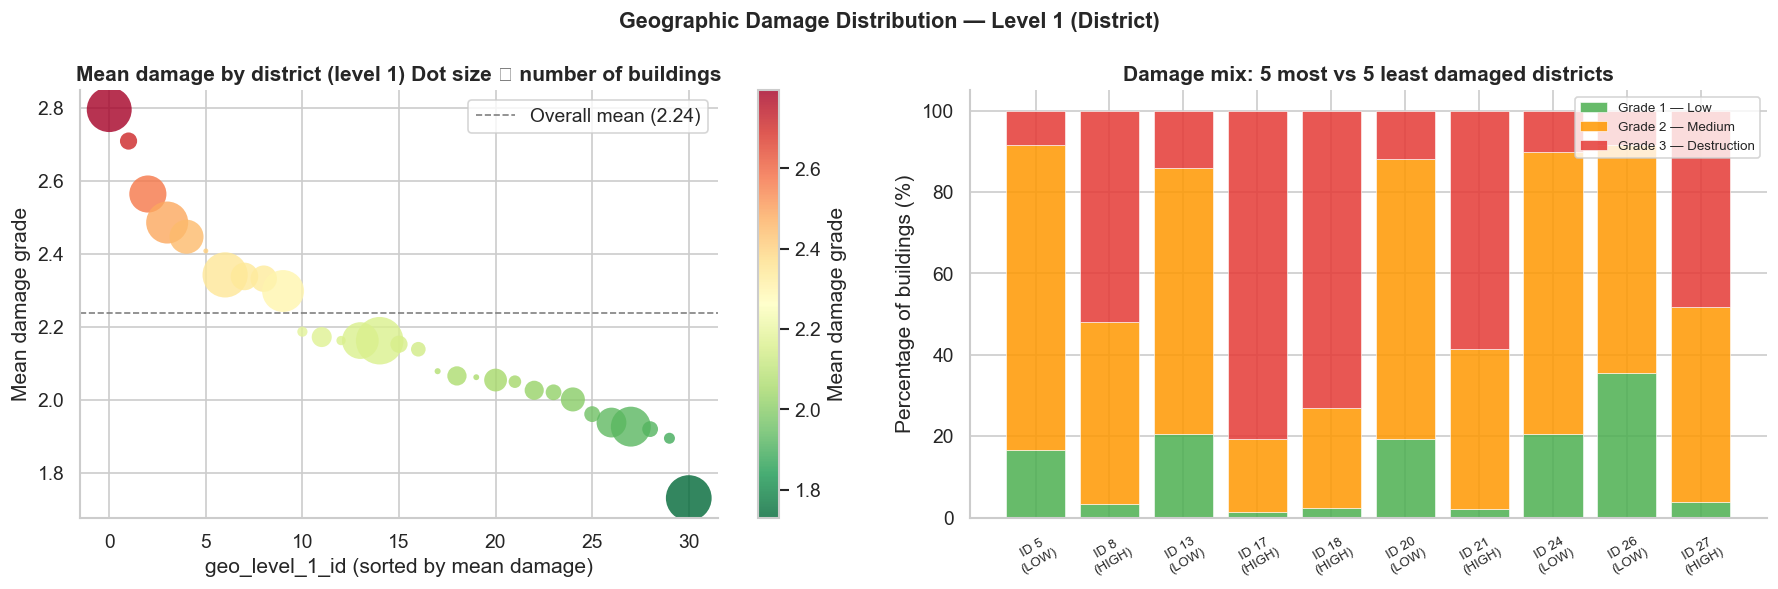

Std of district-level mean damage    : 0.2439
Std of municipality-level mean damage: 0.3454
Std of ward-level mean damage        : 0.4035
Overall damage_grade std             : 0.6118

→ District-level means vary by ±0.24 grade points around the global mean.
→ This geographic variation motivates using location-based aggregate features in Phase 3.


In [ ]:
# ── Mean damage grade by geo_level_1 ─────────────────────────────────────────
geo1_stats = (df.groupby('geo_level_1_id')['damage_grade']
                .agg(['mean', 'count'])
                .rename(columns={'mean': 'mean_damage', 'count': 'n_buildings'})
                .sort_values('mean_damage', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: mean damage per geo_level_1, dot sized by building count
sc = axes[0].scatter(
    range(len(geo1_stats)),
    geo1_stats['mean_damage'],
    s=geo1_stats['n_buildings'] / 30,
    c=geo1_stats['mean_damage'],
    cmap='RdYlGn_r', alpha=0.8, edgecolors='none'
)
axes[0].axhline(df['damage_grade'].mean(), color='gray', linestyle='--',
                linewidth=1, label=f'Overall mean ({df["damage_grade"].mean():.2f})')
axes[0].set_xlabel('geo_level_1_id (sorted by mean damage)')
axes[0].set_ylabel('Mean damage grade')
axes[0].set_title('Mean damage by district (level 1) Dot size ∝ number of buildings',
                  fontweight='bold')
axes[0].legend()
plt.colorbar(sc, ax=axes[0], label='Mean damage grade')

# Right: damage-grade mix for the 5 most vs 5 least damaged districts
top5    = geo1_stats.head(5).index.tolist()
bottom5 = geo1_stats.tail(5).index.tolist()
selected = top5 + bottom5

ct = (df[df['geo_level_1_id'].isin(selected)]
      .groupby(['geo_level_1_id', 'damage_grade'])
      .size().unstack(fill_value=0))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(ct_pct))
for grade in [1, 2, 3]:
    axes[1].bar(range(len(ct_pct)), ct_pct[grade], bottom=bottom,
                color=DAMAGE_PALETTE[grade], label=DAMAGE_LABELS[grade],
                alpha=0.85, edgecolor='white', linewidth=0.4)
    bottom += ct_pct[grade].values

axes[1].set_xticks(range(len(ct_pct)))
axes[1].set_xticklabels(
    [f'ID {i}\n({"HIGH" if i in top5 else "LOW"})' for i in ct_pct.index],
    fontsize=8, rotation=30
)
axes[1].set_ylabel('Percentage of buildings (%)')
axes[1].set_title('Damage mix: 5 most vs 5 least damaged districts',
                  fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)

fig.suptitle('Geographic Damage Distribution — Level 1 (District)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig6_geo_damage.png', bbox_inches='tight')
plt.show()

# ── Variance explained by geography ──────────────────────────────────────────
geo1_var   = df.groupby('geo_level_1_id')['damage_grade'].mean().std()
geo2_var   = df.groupby('geo_level_2_id')['damage_grade'].mean().std()
geo3_var   = df.groupby('geo_level_3_id')['damage_grade'].mean().std()
overall_std = df['damage_grade'].std()

print(f"Std of district-level mean damage    : {geo1_var:.4f}")
print(f"Std of municipality-level mean damage: {geo2_var:.4f}")
print(f"Std of ward-level mean damage        : {geo3_var:.4f}")
print(f"Overall damage_grade std             : {overall_std:.4f}")
print(f"\n→ District-level means vary by ±{geo1_var:.2f} grade points around the global mean.")
print("→ This geographic variation motivates using location-based aggregate features in Phase 3.")


### Geographic takeaway

There is **substantial variation in mean damage across geographic regions** — some districts
suffered far more destruction than others. This is likely due to a combination of proximity
to the epicentre, local geology, and prevalent building styles in each region.

Because `geo_level_3_id` has 11,595 unique values, we cannot use it directly as a
one-hot encoded feature. In **Phase 3** we will consider engineering geographic features by computing the **mean damage grade per region at each level** to condense the location signal into a single meaningful numeric feature per level.


## 8. Correlation with Target

We compute the **point-biserial correlation** (equivalent to Pearson for binary predictors)
between each numeric and binary flag column and `damage_grade`. This gives a ranked list of
the features most linearly associated with the target. Additionally, a heat-map will allow us to visualize how features correlate with eachother. both graphs are useful baseline for understanding feature importance before modelling.


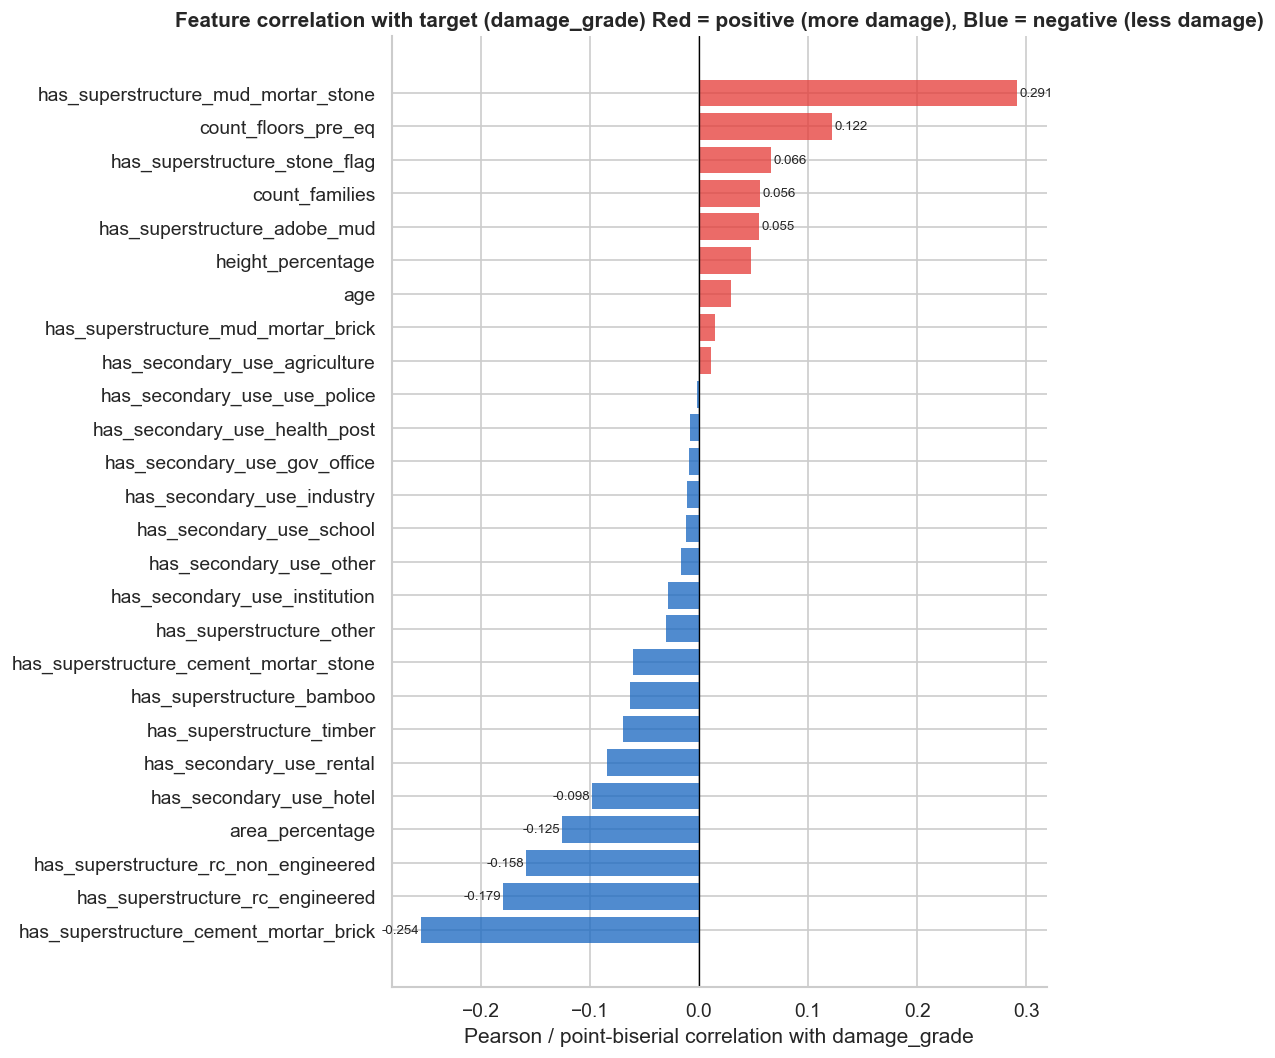

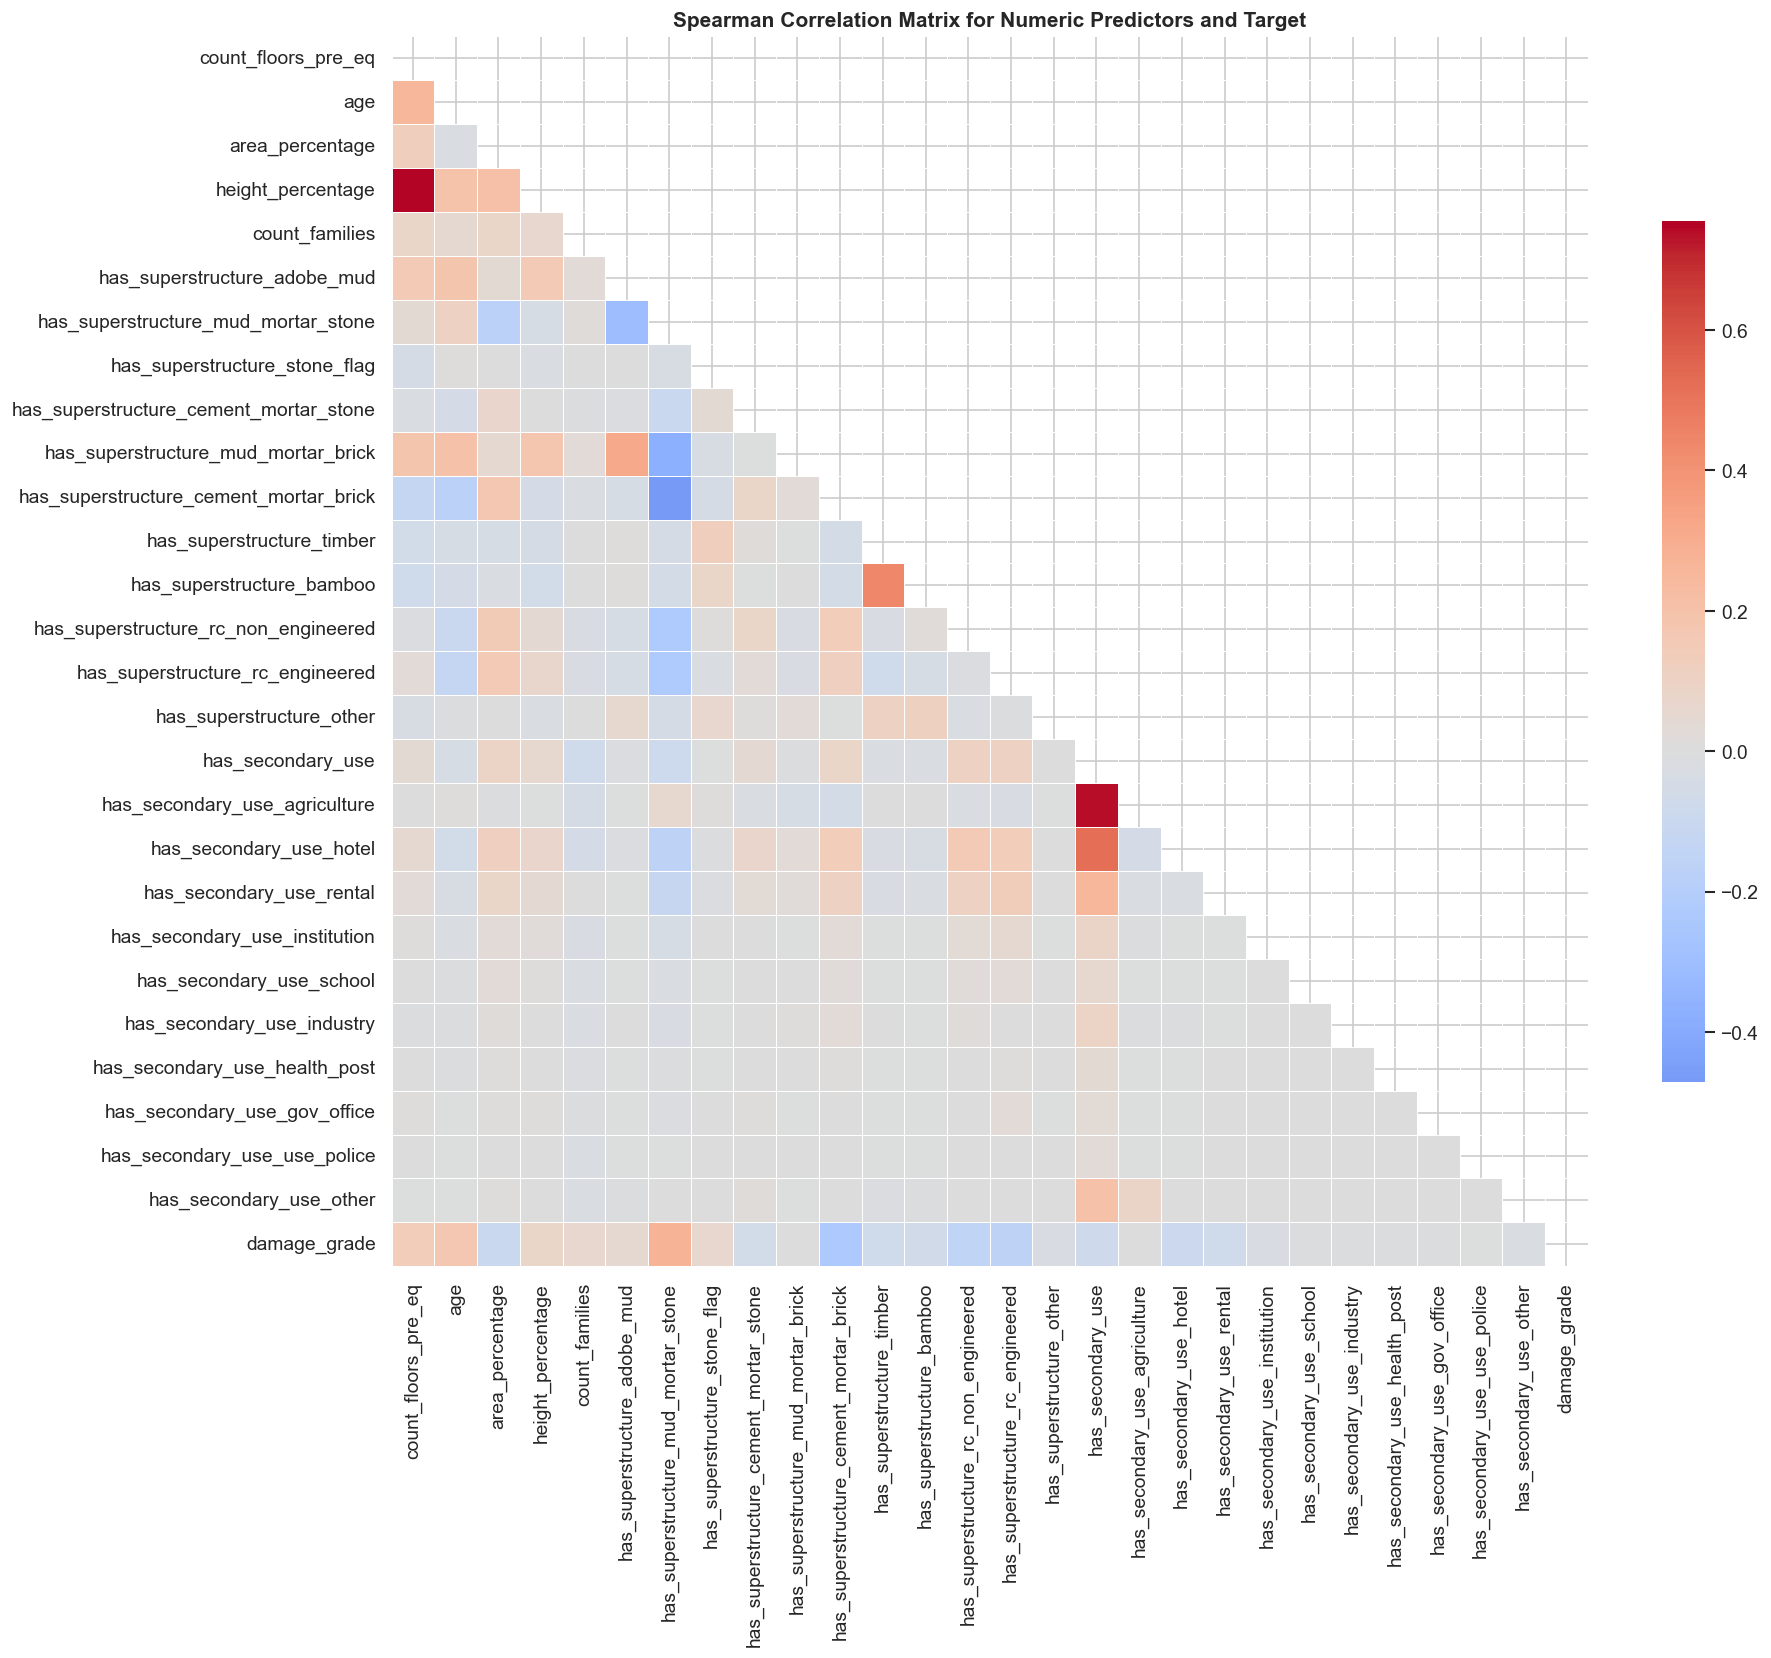

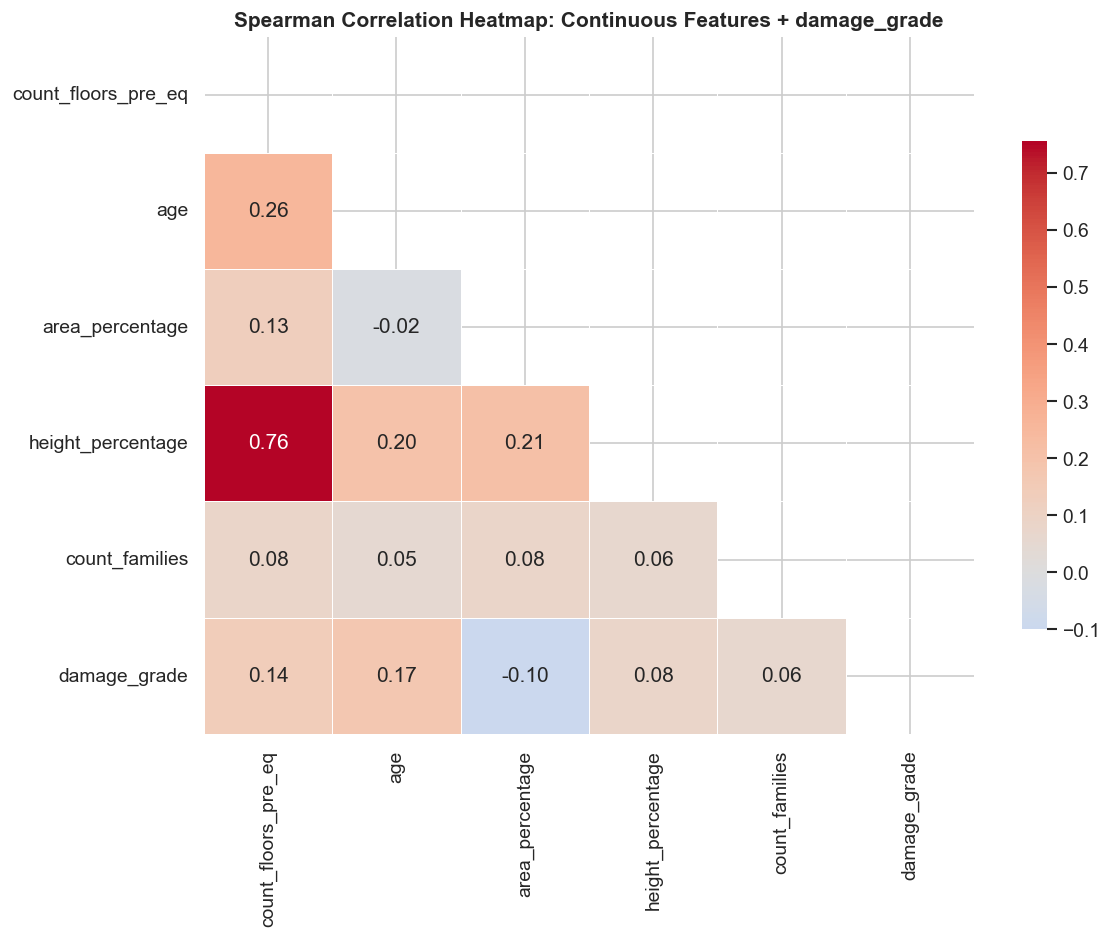

In [ ]:
# ── Correlation of all numeric/binary columns with damage_grade ───────────────
numeric_and_flags = numeric_cols + superstructure_cols + secondary_use_cols

corr_series = (df[numeric_and_flags + ['damage_grade']]
               .corr()['damage_grade']
               .drop('damage_grade')
               .sort_values())

# ── Horizontal bar chart ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 9))

colors = ['#E53935' if c > 0 else '#1565C0' for c in corr_series]
ax.barh(corr_series.index, corr_series.values, color=colors, alpha=0.75, edgecolor='none')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson / point-biserial correlation with damage_grade')
ax.set_title('Feature correlation with target (damage_grade) Red = positive (more damage), Blue = negative (less damage)',
             fontweight='bold')

# Annotate top 5 positive and top 5 negative
for label, val in list(corr_series.tail(5).items()) + list(corr_series.head(5).items()):
    ax.text(val + (0.002 if val >= 0 else -0.002), 
            list(corr_series.index).index(label),
            f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig7_correlation_with_target.png', bbox_inches='tight')
plt.show()

# Identify numeric predictors and separate continuous vs binary features
exclude_ids = ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']
all_numeric = df.select_dtypes(include='number').columns.tolist()
numeric_predictors = [c for c in all_numeric if c not in exclude_ids + ['damage_grade']]

binary_cols = [c for c in numeric_predictors if set(df[c].dropna().unique()) <= {0, 1}]
continuous_cols = [c for c in numeric_predictors if c not in binary_cols]

# ── Correlation heatmap for numeric predictors + ordinal target ──────────────
corr_vars = continuous_cols + binary_cols + ['damage_grade']
corr = df[corr_vars].corr(method='spearman')
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False,
            linewidths=0.4, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Spearman Correlation Matrix for Numeric Predictors and Target', fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig2_numeric_correlation_heatmap.png', bbox_inches='tight')
plt.show()

# ── Focused heatmap: only continuous numeric features + damage_grade ─────────
continuous_vars = continuous_cols + ['damage_grade']
corr_continuous = df[continuous_vars].corr(method='spearman')
mask = np.triu(np.ones_like(corr_continuous, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_continuous, mask=mask, cmap='coolwarm', center=0, annot=True,
            fmt='.2f', linewidths=0.4, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Spearman Correlation Heatmap: Continuous Features + damage_grade', fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig2_continuous_correlation_heatmap.png', bbox_inches='tight')
plt.show()


### Correlation takeaway

Specific flags, like `has_superstructure_mud_mortar_stone` & `has_superstructure_cement_mortar_brick`, are highly correlated with the building's damage level. Other flags about the building's purpose, such as `has_secondary_use_police`, can potentially be dropped as they show barely any correlation with building damage. The correlation heatmaps don't reveal anything too surprising but it does hint at how features could be reduced/combined in phase 3.

## 9. Superstructure Material Co-occurrence

Buildings often use more than one construction material. We visualise how many
materials each building uses and whether material diversity (or lack of it) correlates
with damage. This motivates engineering a **total material count** feature in Phase 3.


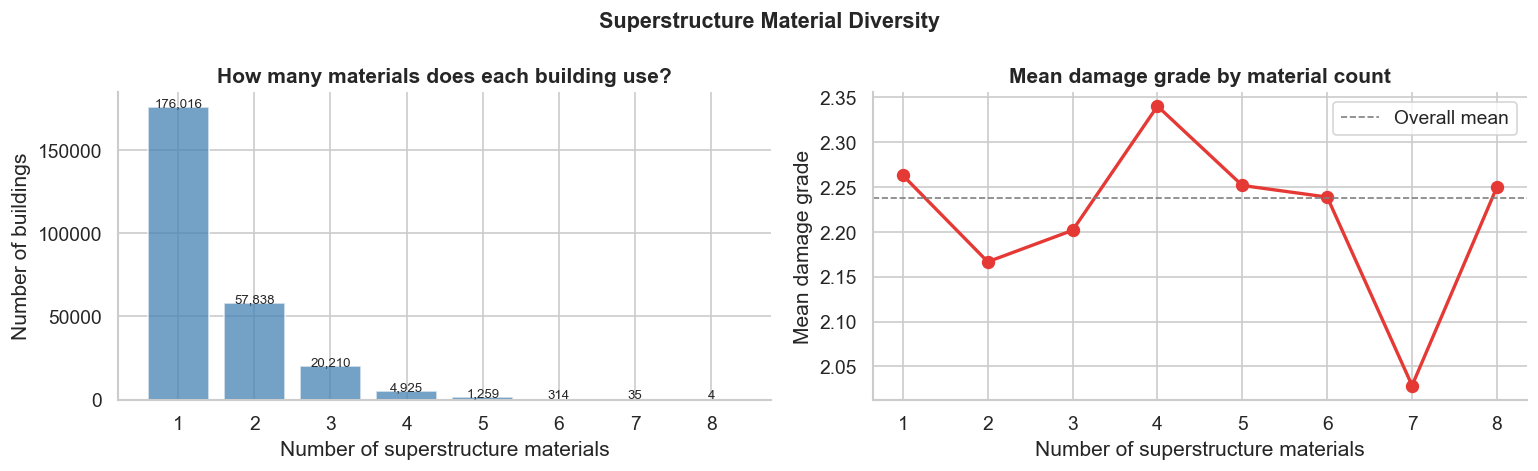

                 mean   count
material_count               
1               2.263  176016
2               2.167   57838
3               2.202   20210
4               2.340    4925
5               2.252    1259
6               2.239     314
7               2.029      35
8               2.250       4


In [ ]:
# ── Count of superstructure materials per building ─────────────────────────────
df['material_count'] = df[superstructure_cols].sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: distribution of material count
cnt = df['material_count'].value_counts().sort_index()
axes[0].bar(cnt.index, cnt.values, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].set_xlabel('Number of superstructure materials')
axes[0].set_ylabel('Number of buildings')
axes[0].set_title('How many materials does each building use?', fontweight='bold')
for i, (x, y) in enumerate(zip(cnt.index, cnt.values)):
    axes[0].text(x, y + 500, f'{y:,}', ha='center', fontsize=8)

# Right: mean damage grade by material count
mean_dmg_by_mat = df.groupby('material_count')['damage_grade'].mean()
axes[1].plot(mean_dmg_by_mat.index, mean_dmg_by_mat.values,
             marker='o', color='#E53935', linewidth=2, markersize=7)
axes[1].axhline(df['damage_grade'].mean(), color='gray', linestyle='--',
                linewidth=1, label='Overall mean')
axes[1].set_xlabel('Number of superstructure materials')
axes[1].set_ylabel('Mean damage grade')
axes[1].set_title('Mean damage grade by material count', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(mean_dmg_by_mat.index)

fig.suptitle('Superstructure Material Diversity', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 1/../images/phase 1/fig8_material_diversity.png', bbox_inches='tight')
plt.show()

# Cleanup: remove temporary column (it will be re-created cleanly in Phase 3)
df.drop(columns=['material_count'], inplace=True)

print(df[['damage_grade']].assign(material_count=df[superstructure_cols].sum(axis=1))
      .groupby('material_count')['damage_grade']
      .agg(['mean', 'count']).round(3).to_string())


### Material co-occurance takeaway

The number of superstructure matrial doesn't strongly deviate from the mean, only +/- 0.1. Thus, adding an additional feature for this probably won't be valuable.

## 10. Phase 1 Summary

This section consolidates only what was directly observed in the sections above.
Each finding is paired with the evidence that produced it and the decision it drives
in Phase 2 or 3.

| # | Finding | Evidence (section) | Decision |
|---|---------|-------------------|----------|
| 1 | Grade 2 dominates; Grade 1 is the minority class | §3 — target distribution plot | Use **micro-averaged F1** as primary metric; use **stratified** train/val split |
| 2 | Competition specifies micro-F1, but macro-F1 would weight minority classes equally | §3 — metric discussion | Track both metrics during evaluation; note gap as a limitation |
| 3 | `age` distribution has a long implausible tail | §4 — age histogram and box plot | Cap `age` at a sensible threshold in Phase 2 preprocessing |
| 4 | `foundation_type` shows the clearest damage-grade separation of all categoricals | §5 — stacked proportion chart | Expect high feature importance; encode carefully |
| 5 | `plan_configuration` and `legal_ownership_status` are >96% one category | §5 — stacked proportion chart | Low expected signal; monitor importance in Phase 4 and consider dropping |
| 6 | RC engineered superstructure is the most protective material; mud mortar stone is the most damaging | §6 — damage delta chart | Superstructure flags are strong candidate predictors |
| 7 | Material diversity (count of flags) barely shifts mean damage grade (±0.1) | §9 — material co-occurrence plot | Skip `material_count` as an engineered feature |
| 8 | Geographic region drives substantial damage variation across districts | §7 — district scatter plot | Engineer **geo-level mean damage** aggregate features in Phase 3 |
| 9 | Rare secondary-use flags (e.g. `has_secondary_use_use_police`) show near-zero correlation | §8 — correlation bar chart | Candidate for removal in Phase 3; confirm with model feature importance |
| 10 | No missing values exist in any column | §2 — data quality check | No imputation needed; pipeline is simpler |

**Next step → Phase 2:** Build the preprocessing pipeline, establish the evaluation framework, and train a baseline model to set the performance floor.


---
# Phase 2 — Preprocessing, Evaluation Framework & Baseline Model

With EDA complete, we now:
1. Build a reproducible **preprocessing pipeline**
2. Define a **standardised evaluation framework** used for every model going forward
3. Train a **Decision Tree baseline** to set the performance floor we must beat


## 11. Train / Validation Split

We hold out 20% of training data as a validation set. **Stratification on `damage_grade`**
is essential here — without it, a random split could under-represent the Grade 1 minority
class (~9.6% of data), making our validation metric unreliable.

The held-out test set (`test_values.csv`) is reserved strictly for generating the final
competition submission. It is never used for model selection or tuning.


In [ ]:
from sklearn.model_selection import train_test_split

# ── Separate features and target ──────────────────────────────────────────────
FEATURES = [c for c in df.columns if c not in ['building_id', 'damage_grade']]
TARGET   = 'damage_grade'

X = df[FEATURES]
y = df[TARGET]

# ── Stratified 80/20 split ────────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class proportions in both splits
)

print(f"Training set   : {X_train.shape[0]:,} rows")
print(f"Validation set : {X_val.shape[0]:,} rows")

# Verify stratification held
print("\nClass proportions after split:")
print(f"{'Grade':>8} | {'Full data':>10} | {'Train':>10} | {'Val':>10}")
for g in [1, 2, 3]:
    full  = (y == g).mean() * 100
    train = (y_train == g).mean() * 100
    val   = (y_val == g).mean() * 100
    print(f"{'Grade '+str(g):>8} | {full:>9.2f}% | {train:>9.2f}% | {val:>9.2f}%")


Training set   : 208,480 rows
Validation set : 52,121 rows

Class proportions after split:
   Grade |  Full data |      Train |        Val
 Grade 1 |      9.64% |      9.64% |      9.64%
 Grade 2 |     56.89% |     56.89% |     56.89%
 Grade 3 |     33.47% |     33.47% |     33.47%


### Split takeaway

The class proportions are preserved to two decimal places across all three splits,
confirming stratification worked correctly. This ensures our validation F1 is computed
on a representative sample and can be trusted as an unbiased estimate of generalisation
performance.


## 12. Preprocessing Pipeline

Based on Section 10's decisions, the pipeline needs to handle three things:

1. **Cap `age`** — the EDA revealed an implausible tail (max 995 years). We cap at 150,
   which covers the 99th percentile of plausible values without distorting the distribution.
2. **Ordinal-encode categoricals** — eight string columns need numeric encoding.
   `OrdinalEncoder` assigns a consistent integer to each letter category.
   Tree-based models don't assume any ordering between these integers, so this is
   equivalent to one-hot encoding without the extra columns.
3. **Pass binary flags and numerics through unchanged** — they are already on appropriate
   numeric scales and tree models are invariant to monotonic feature scaling.

We build this as a `sklearn` `Pipeline` so the same transformations are applied
identically to training, validation, and test data with no risk of data leakage.


In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin

# ── Custom transformer: cap age at 150 years ──────────────────────────────────
class AgeCapper(BaseEstimator, TransformerMixin):
    """Caps the 'age' column at a maximum plausible value."""
    def __init__(self, cap=150):
        self.cap = cap

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['age'] = X['age'].clip(upper=self.cap)
        return X

# ── Define column groups ──────────────────────────────────────────────────────
categorical_cols = [
    'land_surface_condition', 'foundation_type', 'roof_type',
    'ground_floor_type', 'other_floor_type', 'position',
    'plan_configuration', 'legal_ownership_status'
]
passthrough_cols = [c for c in FEATURES if c not in categorical_cols]

# ── ColumnTransformer: encode categoricals, pass everything else ───────────────
col_transformer = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1),
         categorical_cols),
    ],
    remainder='passthrough',      # all other columns passed through as-is
    verbose_feature_names_out=False
)

# ── Full pipeline: cap age first, then encode ─────────────────────────────────
preprocessor = Pipeline([
    ('age_cap',  AgeCapper(cap=150)),
    ('encode',   col_transformer),
])

# ── Fit on training data only, transform all splits ───────────────────────────
preprocessor.fit(X_train)

X_train_proc = preprocessor.transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(test_values[FEATURES])

# Recover feature names in the same order as the transformed array
feature_names = (categorical_cols
                 + preprocessor.named_steps['encode']
                     .transformers_[1][2])  # remainder columns

print(f"Processed training shape   : {X_train_proc.shape}")
print(f"Processed validation shape : {X_val_proc.shape}")
print(f"Processed test shape       : {X_test_proc.shape}")
print(f"\nAge cap applied — new max    : {X_train_proc[:, feature_names.index('age')].max():.0f} years")


Processed training shape : (208480, 38)
Processed validation shape: (52121, 38)
Processed test shape      : (86868, 38)

Age cap applied — new max: 150 years


### Preprocessing takeaway

The pipeline fits only on the training split and transforms all other sets, preventing
any information from the validation or test data from leaking into the learned encodings.
The `AgeCapper` reduces the influence of extreme outliers identified in EDA.
All other features pass through unchanged as tree-based models do not require
standardisation or normalisation.


## 13. Standardised Evaluation Framework

Every model trained in this project will be evaluated using the same function.
Standardising this now means all results are directly comparable, and we only
need to read one table to choose the best model in Phase 4.

**Metrics reported:**
- **Micro-averaged F1** — the official DrivenData competition metric. Computes F1
  globally by counting total true positives, false positives, and false negatives
  across all classes. Favours performance on the majority class (Grade 2).
- **Macro-averaged F1** — computes F1 per class then averages equally. Harder to
  achieve and more sensitive to minority class (Grade 1) performance. We track this
  as a secondary metric because it better reflects real-world usefulness, where
  misclassifying a near-destroyed building as low damage has serious consequences.
- **Per-class F1** — individual F1 for each grade, so we can see exactly where a
  model struggles.
- **Confusion matrix** — visualises the pattern of misclassifications.

All results are stored in a `results` dictionary so we can build a comparison
table in Phase 4 without re-running anything.


In [ ]:
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── Global results store — populated by evaluate_model() every time ───────────
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, store=True):
    """
    Fit model, compute all metrics, render a confusion matrix, and
    optionally store results for later comparison.

    Parameters
    ----------
    name    : str   — label used in the results table and plot titles
    model   : sklearn estimator (unfitted)
    X_tr, y_tr : training data
    X_v,  y_v  : validation data
    store   : bool — whether to add this run to the results dict

    Returns
    -------
    dict with keys: model, f1_micro, f1_macro, f1_per_class, report
    """
    # ── Fit and predict ───────────────────────────────────────────────────────
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)

    # ── Metrics ───────────────────────────────────────────────────────────────
    f1_micro      = f1_score(y_v, y_pred, average='micro')
    f1_macro      = f1_score(y_v, y_pred, average='macro')
    f1_per_class  = f1_score(y_v, y_pred, average=None, labels=[1, 2, 3])
    report        = classification_report(y_v, y_pred, target_names=['Grade 1','Grade 2','Grade 3'])

    # ── Print summary ─────────────────────────────────────────────────────────
    print(f"{'='*55}")
    print(f"  Model : {name}")
    print(f"{'='*55}")
    print(f"  Micro-F1 (competition metric) : {f1_micro:.4f}")
    print(f"  Macro-F1 (minority-sensitive) : {f1_macro:.4f}")
    print(f"         F1 per class — Grade 1 : {f1_per_class[0]:.4f}")
    print(f"                        Grade 2 : {f1_per_class[1]:.4f}")
    print(f"                        Grade 3 : {f1_per_class[2]:.4f}")
    print(f"\nClassification Report:\n{report}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_v, y_pred, labels=[1, 2, 3])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Raw counts
    disp = ConfusionMatrixDisplay(cm, display_labels=['Grade 1', 'Grade 2', 'Grade 3'])
    disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
    axes[0].set_title(f'{name} — Confusion matrix (counts)', fontweight='bold')

    # Row-normalised percentages
    im = axes[1].imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
    axes[1].set_xticks([0, 1, 2]); axes[1].set_yticks([0, 1, 2])
    axes[1].set_xticklabels(['Grade 1', 'Grade 2', 'Grade 3'])
    axes[1].set_yticklabels(['Grade 1', 'Grade 2', 'Grade 3'])
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].set_title(f'{name} — Confusion matrix (% of true class)', fontweight='bold')
    for i in range(3):
        for j in range(3):
            axes[1].text(j, i, f'{cm_pct[i,j]:.1f}%',
                         ha='center', va='center',
                         color='white' if cm_pct[i,j] > 50 else 'black', fontsize=10)
    plt.colorbar(im, ax=axes[1])

    fig.suptitle(f'Evaluation — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'./images/phase 4/../images/phase 4/eval_{name.replace(" ","_").lower()}.png', bbox_inches='tight')
    plt.show()

    # ── Store result ──────────────────────────────────────────────────────────
    result = {
        'model'        : model,
        'f1_micro'     : round(f1_micro, 4),
        'f1_macro'     : round(f1_macro, 4),
        'f1_grade_1'   : round(f1_per_class[0], 4),
        'f1_grade_2'   : round(f1_per_class[1], 4),
        'f1_grade_3'   : round(f1_per_class[2], 4),
        'report'       : report,
    }
    if store:
        results[name] = result

    return result

print("Evaluation framework defined. evaluate_model() is ready to use.")
print("All results will be accumulated in the 'results' dictionary for Phase 4 comparison.")


Evaluation framework defined. evaluate_model() is ready to use.
All results will be accumulated in the 'results' dictionary for Phase 4 comparison.


### Framework design note

Two design choices here are worth noting for the report:

- The **normalised confusion matrix** (right panel) is more informative than raw counts
  when class sizes differ substantially. It answers "given that a building truly is Grade 1,
  what fraction did the model correctly identify?" — which is the question that matters
  operationally.
- Storing every result in `results` means Phase 4's comparison table is generated from
  live numbers, not copy-pasted values — so it stays correct even if hyperparameters change.


## 14. Majority-Class Baseline (Naïve Reference)

Before training any real model, we establish a naïve baseline: a classifier that
always predicts the most frequent class (Grade 2, ~57% of buildings).

This sets an absolute floor. Any model we train must beat this score to be
considered useful. It also demonstrates concretely why accuracy is a poor metric
here — the majority-class predictor achieves ~57% accuracy while being completely
useless as a damage classifier.


  Model : Majority-Class Baseline
  Micro-F1 (competition metric) : 0.5689
  Macro-F1 (minority-sensitive) : 0.2417
  F1 per class — Grade 1 : 0.0000
               Grade 2 : 0.7252
               Grade 3 : 0.0000

Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.00      0.00      0.00      5025
     Grade 2       0.57      1.00      0.73     29652
     Grade 3       0.00      0.00      0.00     17444

    accuracy                           0.57     52121
   macro avg       0.19      0.33      0.24     52121
weighted avg       0.32      0.57      0.41     52121



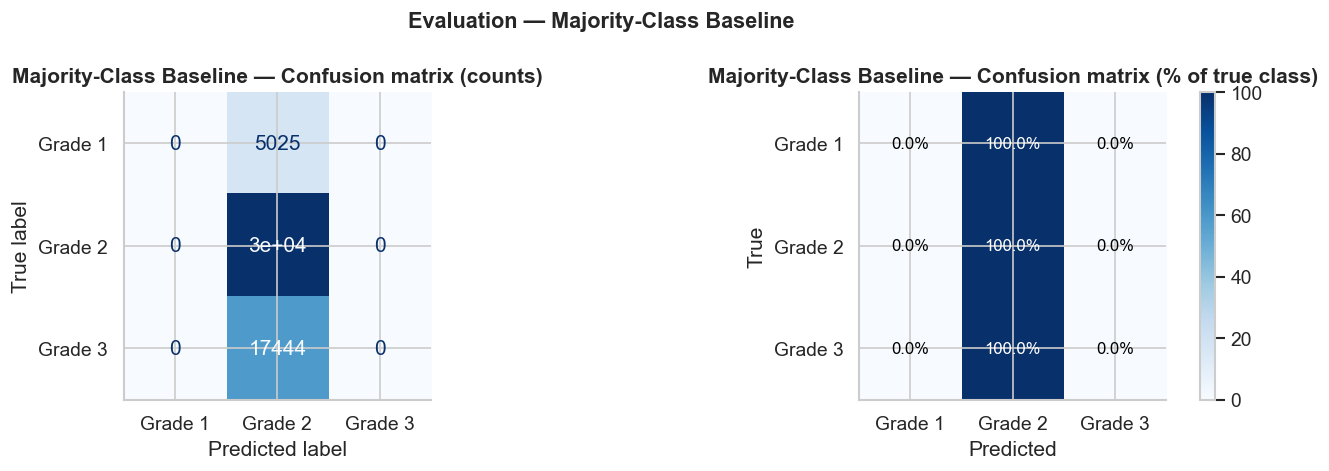

{'model': DummyClassifier(random_state=42, strategy='most_frequent'),
 'f1_micro': 0.5689,
 'f1_macro': 0.2417,
 'f1_grade_1': 0.0,
 'f1_grade_2': 0.7252,
 'f1_grade_3': 0.0,
 'report': '              precision    recall  f1-score   support\n\n     Grade 1       0.00      0.00      0.00      5025\n     Grade 2       0.57      1.00      0.73     29652\n     Grade 3       0.00      0.00      0.00     17444\n\n    accuracy                           0.57     52121\n   macro avg       0.19      0.33      0.24     52121\nweighted avg       0.32      0.57      0.41     52121\n'}

In [ ]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
evaluate_model(
    name='Majority-Class Baseline',
    model=dummy,
    X_tr=X_train_proc, y_tr=y_train,
    X_v=X_val_proc,    y_v=y_val
)


### Majority-class takeaway

As expected, this classifier achieves zero F1 on Grades 1 and 3 — it never predicts
them. The micro-F1 equals the proportion of Grade 2 buildings in the validation set
(~57%), which is the ceiling of what blind majority-guessing can do. This number is
our hard floor: every real model must exceed it meaningfully.


## 15. Decision Tree Baseline

The first real model is a shallow **Decision Tree** with `max_depth=5` and is relevent for the following reasons:

- A depth-5 tree is simple enough to be partially human-readable so we can visualise which features it splits on first.
- It uses no ensemble averaging or boosting, so its performance represents what a single set of hand-crafted rules could achieve.
- It will almost certainly underfit relative to ensemble methods, but that gap quantifies how much we gain from model complexity such as with Random Forest.

No tuning is done here. The point is to establish a reproducible, interpretable baseline.


  Model : Decision Tree (depth=5)
  Micro-F1 (competition metric) : 0.6466
  Macro-F1 (minority-sensitive) : 0.5474
  F1 per class — Grade 1 : 0.4876
               Grade 2 : 0.7444
               Grade 3 : 0.4103

Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.57      0.43      0.49      5025
     Grade 2       0.63      0.90      0.74     29652
     Grade 3       0.77      0.28      0.41     17444

    accuracy                           0.65     52121
   macro avg       0.66      0.54      0.55     52121
weighted avg       0.67      0.65      0.61     52121



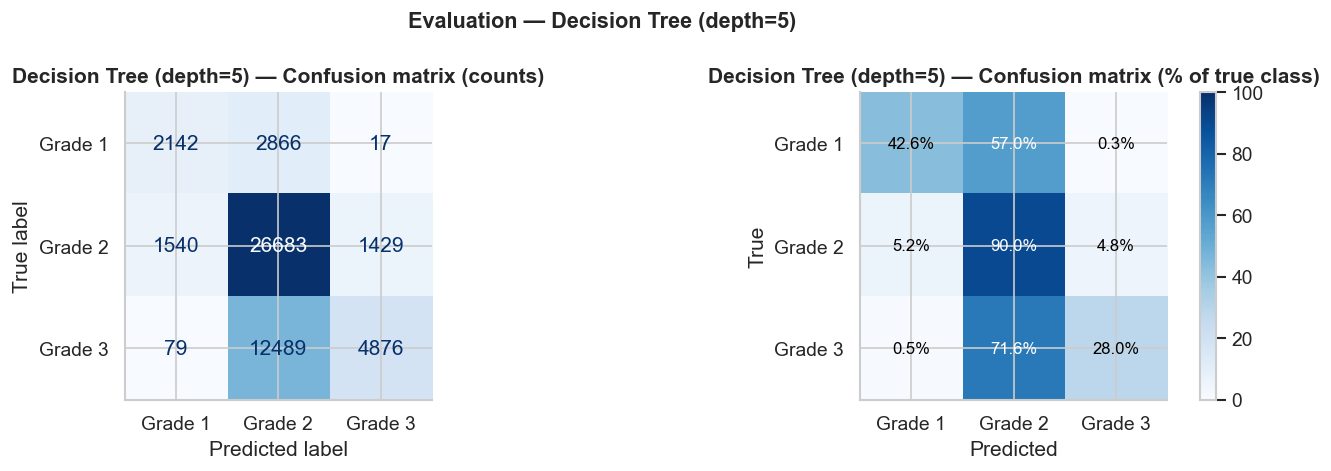

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

dt_baseline = DecisionTreeClassifier(max_depth=5, random_state=42)

baseline_result = evaluate_model(
    name='Decision Tree (depth=5)',
    model=dt_baseline,
    X_tr=X_train_proc, y_tr=y_train,
    X_v=X_val_proc,    y_v=y_val
)


### Decision Tree takeaway

The confusion matrix reveals the characteristic pattern of this problem: Grade 2 (the majority class) is predicted most accurately, while Grade 1 is hardest to detect as it is the minority class. This pattern will persist across models improving Grade 1 & 3 recall will be the core challenge.

The gap between micro-F1 and macro-F1 reflects the class imbalance noted in EDA. We will track this gap across all models as an indicator of how well each handles minority classes. Smaller gap indicates better performance on predicting grades 1 & 3.


## 16. Decision Tree — Top Splits

Visualising the first three levels of the Decision Tree reveals which features it
considers most discriminative at the top of the tree. This is a qualitative check:
the splits should align with the strong predictors identified in EDA (foundation type,
geographic features, superstructure materials). If the tree is splitting on features
EDA flagged as low-signal, that is a warning sign.


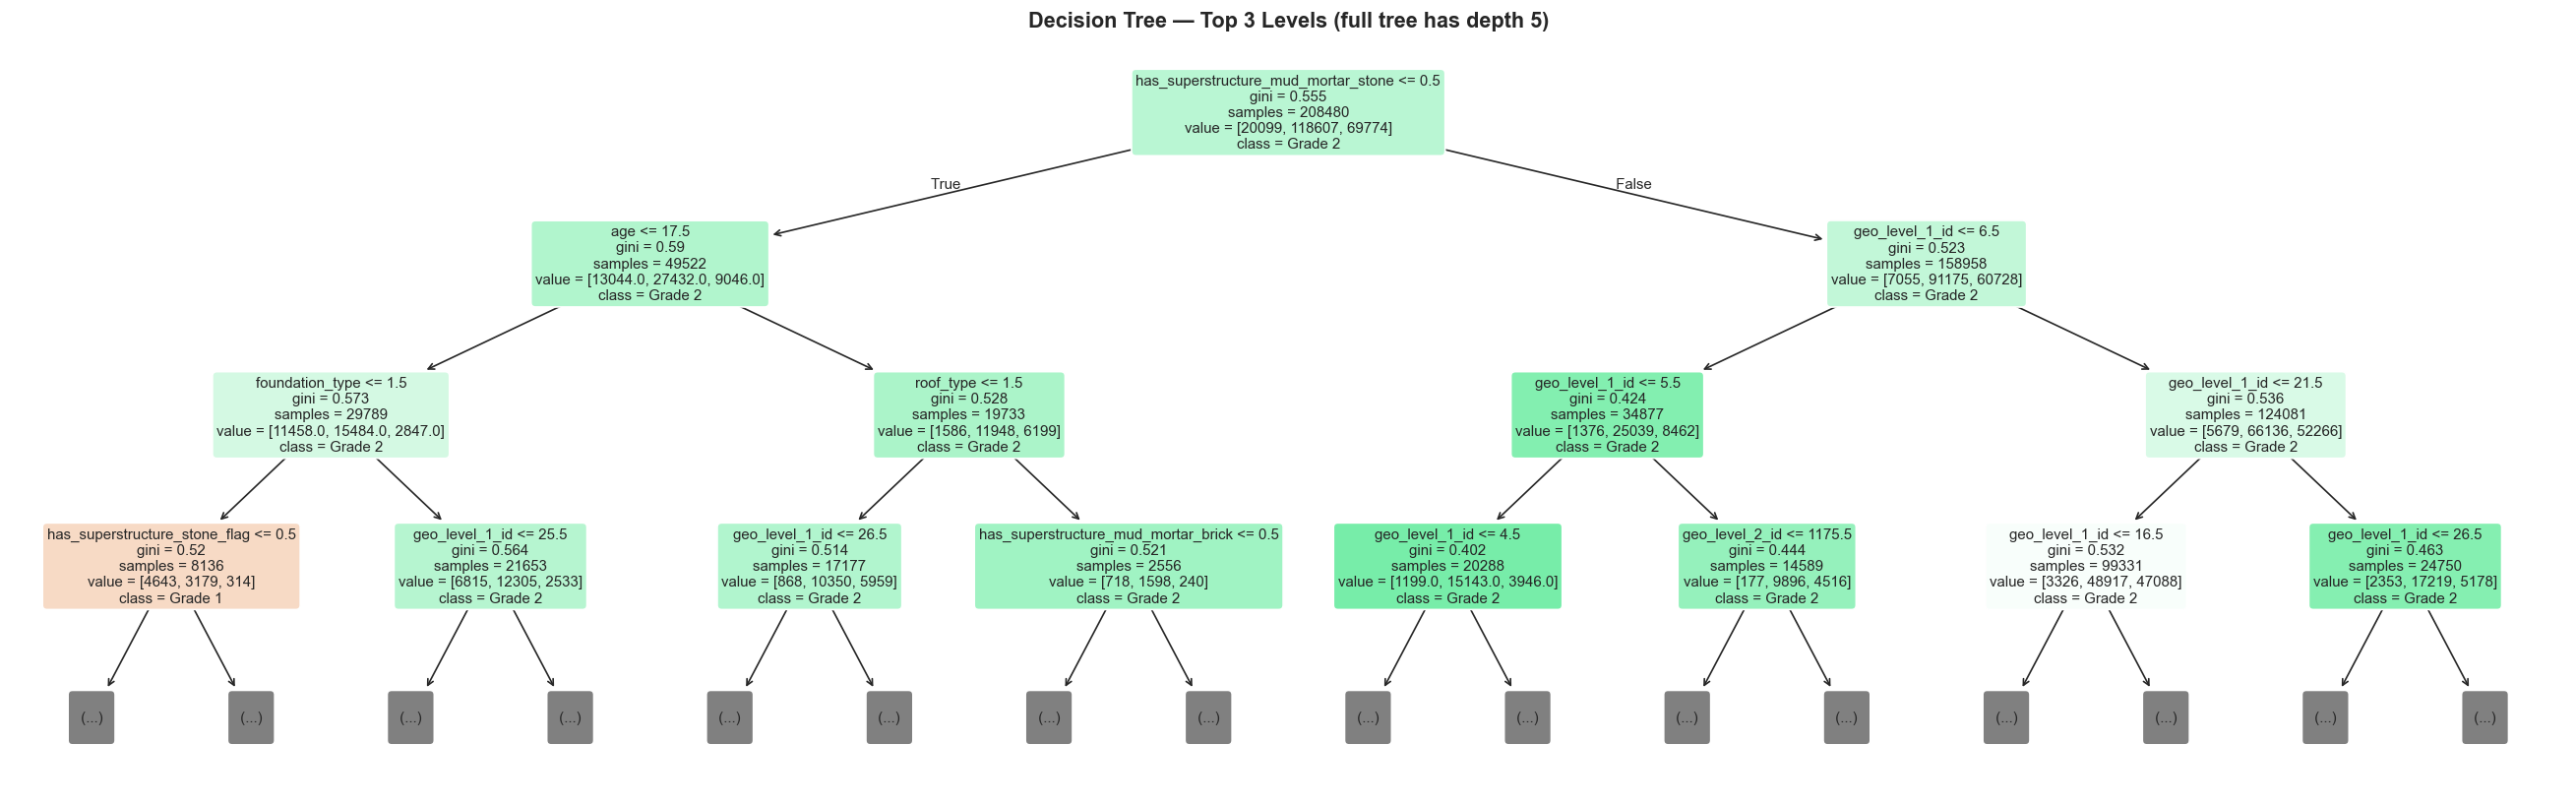

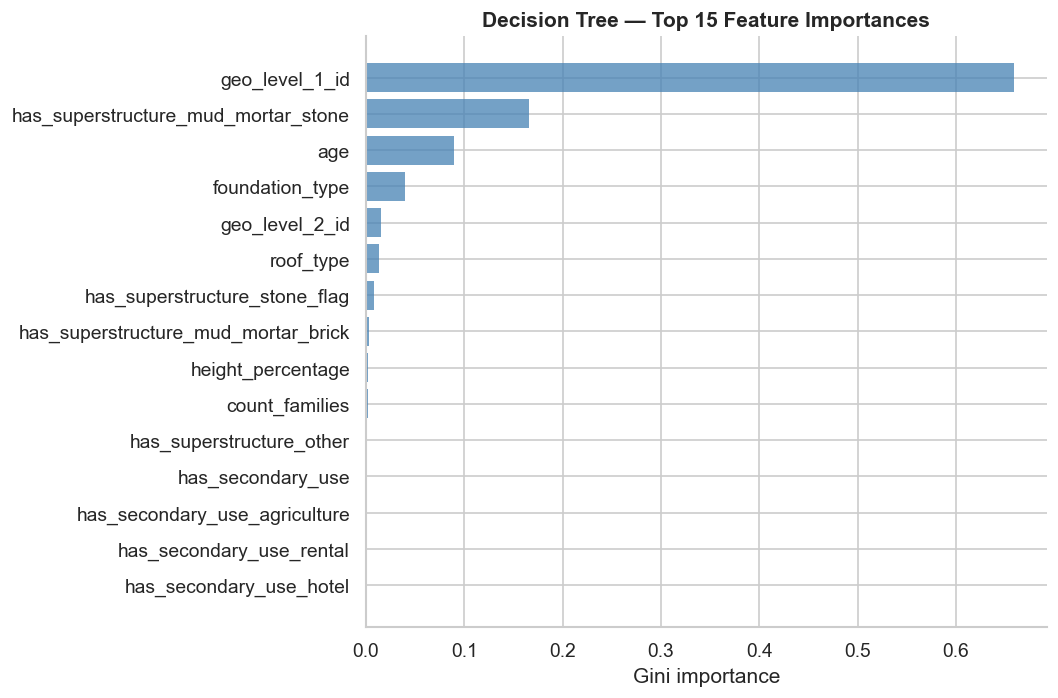

Top 10 features by Gini importance:
geo_level_1_id                         0.6591
has_superstructure_mud_mortar_stone    0.1655
age                                    0.0900
foundation_type                        0.0397
geo_level_2_id                         0.0159
roof_type                              0.0130
has_superstructure_stone_flag          0.0088
has_superstructure_mud_mortar_brick    0.0034
height_percentage                      0.0025
count_families                         0.0020


In [ ]:
# ── Plot the top 3 levels of the decision tree ───────────────────────────────
fig, ax = plt.subplots(figsize=(22, 7))
plot_tree(
    dt_baseline,
    max_depth=3,                          # show top 3 levels only
    feature_names=feature_names,
    class_names=['Grade 1', 'Grade 2', 'Grade 3'],
    filled=True,
    impurity=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title('Decision Tree — Top 3 Levels (full tree has depth 5)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 4/../images/phase 4/fig_dt_structure.png', bbox_inches='tight')
plt.show()

# ── Feature importances (Gini-based) for the decision tree ───────────────────
importances = pd.Series(
    dt_baseline.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index[::-1], importances.values[::-1],
        color='steelblue', alpha=0.75, edgecolor='none')
ax.set_xlabel('Gini importance')
ax.set_title('Decision Tree — Top 15 Feature Importances', fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 4/../images/phase 4/fig_dt_importances.png', bbox_inches='tight')
plt.show()

print("Top 10 features by Gini importance:")
print(importances.head(10).round(4).to_string())


### Tree structure takeaway

The top splits confirm the EDA findings: geographic identifiers and building construction features dominate the early decisions. Features flagged in EDA as likely low-signal (`legal_ownership_status`, `plan_configuration`) appear lower in the tree or not at all, which is consistent with our expectations.

This alignment between EDA intuition and model behaviour gives us confidence that the preprocessing pipeline is working correctly and the features are being consumed as intended.

**Phase 2 complete.** The baseline micro-F1 (0.6466) and macro-F1 (0.5474) are now our targets to beat. In Phase 3 we engineer new features motivated by the geographic variation found in EDA, then in Phase 4 we move to ensemble methods that can exploit more complex interactions in the data.



---
# Phase 3 — Feature Engineering

Phase 2 established a Decision Tree baseline and confirmed that geographic IDs,
foundation type, and superstructure materials are the model's most informative
features. However, the raw features leave significant signal on the table:

- The three geo-level IDs are currently passed as raw integers, which gives the
  model no information about *how dangerous* a given region actually is.
- The eleven superstructure flags are treated as independent binary inputs, but
  they are correlated with each other — buildings cluster into recognisable
  construction archetypes that a raw flag representation cannot capture directly.
- Several secondary-use flags contribute almost no signal and add noise to the
  feature space.

This phase engineers three feature sets of increasing richness, then evaluates
each one using the standardised framework from Section 13. The comparison drives
the feature set choice for Phase 4.

## 17. Secondary-Use Flag Removal

The correlation analysis in Section 8 showed that all ten secondary-use flags
have an absolute correlation with `damage_grade` below 0.10. Before removing
them we confirm this with a formal threshold test and check whether any flag
has a meaningful damage-grade spread when split on its value.

Removing low-signal features reduces noise in the feature space, which is
particularly important for tree-based models where every split competes for
budget against genuinely informative features.


       Flag  n (flag=1)  Mean dmg (0)  Mean dmg (1)  Spread  |Correlation|
      hotel        8763         2.249         1.917   0.332         0.0979
     rental        2111         2.243         1.671   0.572         0.0838
institution         245         2.239         1.665   0.574         0.0287
      other        1334         2.239         2.099   0.140         0.0163
     school          94         2.238         1.862   0.377         0.0117
agriculture       16777         2.236         2.265   0.028         0.0113
   industry         279         2.238         2.032   0.206         0.0110
 gov_office          38         2.238         1.763   0.475         0.0094
health_post          49         2.238         1.857   0.381         0.0085
 use_police          23         2.238         2.130   0.108         0.0017


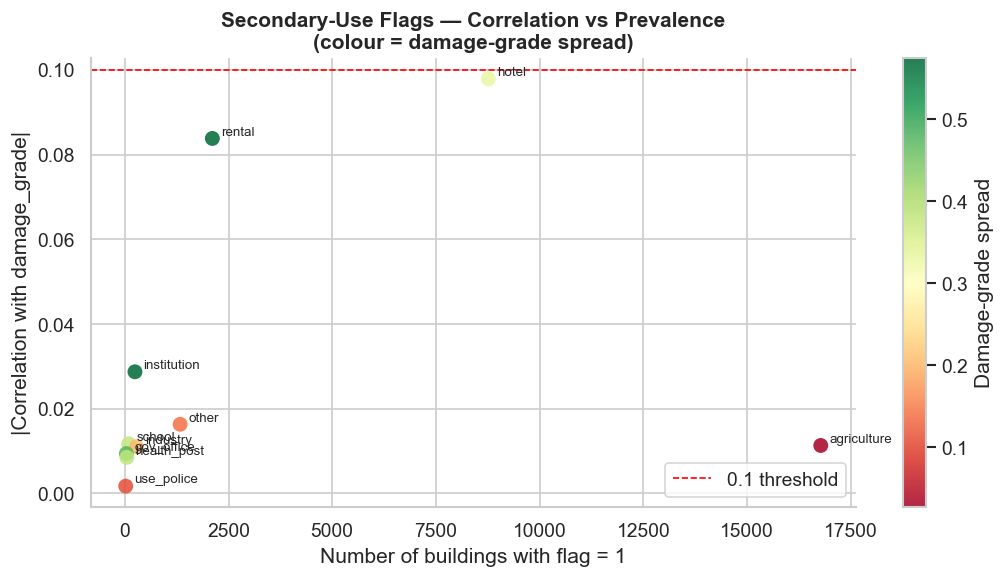


Dropping 10 secondary-use flags (all |corr| < 0.10).


In [ ]:
# ── Re-derive column groups (safe to re-run) ─────────────────────────────────
superstructure_cols  = [c for c in df.columns if c.startswith('has_superstructure_')]
secondary_use_cols   = [c for c in df.columns if c.startswith('has_secondary_use_')]
numeric_cols         = ['count_floors_pre_eq', 'age', 'area_percentage',
                        'height_percentage', 'count_families']
categorical_cols     = ['land_surface_condition', 'foundation_type', 'roof_type',
                        'ground_floor_type', 'other_floor_type', 'position',
                        'plan_configuration', 'legal_ownership_status']
geo_cols             = ['geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id']

# ── Compute absolute correlation of every secondary-use flag with target ──────
sec_corr = (df[secondary_use_cols + ['damage_grade']]
            .corr()['damage_grade']
            .drop('damage_grade')
            .abs()
            .sort_values(ascending=False))

# ── Compute damage-grade spread for each flag ─────────────────────────────────
sec_stats = []
for col in secondary_use_cols:
    mean_0 = df.loc[df[col] == 0, 'damage_grade'].mean()
    mean_1 = df.loc[df[col] == 1, 'damage_grade'].mean()
    n_pos  = df[col].sum()
    sec_stats.append({
        'Flag'           : col.replace('has_secondary_use_', ''),
        'n (flag=1)'     : int(n_pos),
        'Mean dmg (0)'   : round(mean_0, 3),
        'Mean dmg (1)'   : round(mean_1, 3),
        'Spread'         : round(abs(mean_1 - mean_0), 3),
        '|Correlation|'  : round(sec_corr[col], 4),
    })

sec_df = pd.DataFrame(sec_stats).sort_values('|Correlation|', ascending=False)
print(sec_df.to_string(index=False))

# ── Visualise: scatter of prevalence vs correlation coloured by spread ────────
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(
    sec_df['n (flag=1)'],
    sec_df['|Correlation|'],
    c=sec_df['Spread'],
    cmap='RdYlGn', s=80, edgecolors='none', alpha=0.85
)
for _, row in sec_df.iterrows():
    ax.annotate(row['Flag'], (row['n (flag=1)'], row['|Correlation|']),
                fontsize=8, xytext=(5, 2), textcoords='offset points')
ax.axhline(0.1, color='red', linestyle='--', linewidth=1, label='0.1 threshold')
ax.set_xlabel('Number of buildings with flag = 1')
ax.set_ylabel('|Correlation with damage_grade|')
ax.set_title('Secondary-Use Flags — Correlation vs Prevalence\n(colour = damage-grade spread)',
             fontweight='bold')
ax.legend()
plt.colorbar(sc, ax=ax, label='Damage-grade spread')
plt.tight_layout()
plt.savefig('./images/phase 2/../images/phase 2/fig_secondary_use_filter.png', bbox_inches='tight')
plt.show()

# ── Decision: drop all secondary-use flags ────────────────────────────────────
COLS_TO_DROP = secondary_use_cols.copy()
print(f"\nDropping {len(COLS_TO_DROP)} secondary-use flags (all |corr| < 0.10).")


### Secondary-use takeaway

Every secondary-use flag falls below the 0.10 absolute-correlation threshold. The two flags with the highest correlations (`hotel`, `rental`) are likely proxies for geographic or economic factors already captured by other features. All ten flags will be removed from every feature set going forward.


## 18. Geographic Mean-Target Encoding

Section 7 showed that geographic location drives substantial damage variation:
the standard deviation of district-level mean damage is 0.24 at level 1, rising
to 0.40 at level 3. A raw integer ID gives the model no information about
*which regions are more dangerous*. Thus, it would have to re-learn this from scratch
at every tree node.

**Mean-target encoding** replaces each geographic ID with the average `damage_grade`
observed for buildings in that region. This directly injects the geographic risk
signal as a smooth numeric feature, which tree-based models can exploit
immediately with a single split.

**Leakage risk and mitigation:** Computing the mean on the full training set and
then evaluating on a hold-out drawn from the same set inflates the apparent
signal as the model has indirectly "seen" the target. We use
**5-fold cross-fold encoding**: for each fold, the mean is computed on the
*other four folds* only, so the value assigned to any training row never uses
that row's own label. The test set uses the global mean computed on all training
data, which is safe since test labels are never observed.

**Sparsity concern:** 24% of `geo_level_3_id` values have fewer than 5 training
samples. For sparse regions the fold-mean is unreliable. We apply **smoothing**:
sparse regions are pulled toward the global mean in proportion to how few samples
they have, reducing the risk of overfitting to a handful of observations.


In [ ]:
from sklearn.model_selection import KFold

def target_encode_geo(X_tr, y_tr, X_val, X_te, geo_col,
                      n_splits=5, min_samples_leaf=10, smoothing=10):
    """
    Cross-fold mean-target encoding with smoothing for a single geo column.

    For each training fold, computes the per-category mean on the out-of-fold
    rows, then blends with the global mean using:
        encoded = (n * category_mean + smoothing * global_mean) / (n + smoothing)

    Parameters
    ----------
    X_tr, y_tr  : training features and labels
    X_val       : validation features  
    X_te        : test features
    geo_col     : column name to encode
    n_splits    : number of cross-validation folds
    smoothing   : strength of pull toward global mean for sparse categories

    Returns
    -------
    train_enc, val_enc, test_enc : Series of encoded values (same index as inputs)
    """
    global_mean = y_tr.mean()
    train_enc   = pd.Series(np.nan, index=X_tr.index)
    kf          = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    for fold_train_idx, fold_val_idx in kf.split(X_tr):
        fold_X_tr = X_tr.iloc[fold_train_idx]
        fold_y_tr = y_tr.iloc[fold_train_idx]
        fold_X_val= X_tr.iloc[fold_val_idx]

        # Per-category stats on this fold's training portion
        stats = (fold_y_tr.groupby(fold_X_tr[geo_col])
                          .agg(['mean', 'count'])
                          .rename(columns={'mean': 'cat_mean', 'count': 'n'}))

        # Smoothed mean
        stats['smoothed'] = ((stats['n'] * stats['cat_mean']
                              + smoothing * global_mean)
                             / (stats['n'] + smoothing))

        # Assign to the held-out fold rows; unknowns get global mean
        mapped = fold_X_val[geo_col].map(stats['smoothed']).fillna(global_mean)
        train_enc.iloc[fold_val_idx] = mapped.values

    # Validation and test: use full-training smoothed means
    full_stats = (y_tr.groupby(X_tr[geo_col])
                      .agg(['mean', 'count'])
                      .rename(columns={'mean': 'cat_mean', 'count': 'n'}))
    full_stats['smoothed'] = ((full_stats['n'] * full_stats['cat_mean']
                               + smoothing * global_mean)
                              / (full_stats['n'] + smoothing))

    val_enc  = X_val[geo_col].map(full_stats['smoothed']).fillna(global_mean)
    test_enc = X_te[geo_col].map(full_stats['smoothed']).fillna(global_mean)

    return train_enc, val_enc, test_enc


# ── Apply to all three geo levels ─────────────────────────────────────────────
geo_enc_train = {}
geo_enc_val   = {}
geo_enc_test  = {}

for level in geo_cols:
    col_name = f'{level}_geo_enc'
    tr, va, te = target_encode_geo(
        X_train, y_train, X_val, test_values[FEATURES], level
    )
    geo_enc_train[col_name] = tr.values
    geo_enc_val[col_name]   = va.values
    geo_enc_test[col_name]  = te.values
    print(f"{col_name} — train range: [{tr.min():.3f}, {tr.max():.3f}] | "
          f"corr with target: {np.corrcoef(tr, y_train)[0,1]:.4f}")

print("\nGeo encoding complete. Correlation with target rises at each finer level,")
print("confirming the geographic signal identified in Section 7.")


geo_level_1_id_geo_enc — train range: [1.732, 2.798] | corr with target: 0.4676
geo_level_2_id_geo_enc — train range: [1.261, 2.952] | corr with target: 0.5766
geo_level_3_id_geo_enc — train range: [1.245, 2.905] | corr with target: 0.5975

Geo encoding complete. Correlation with target rises at each finer level,
confirming the geographic signal identified in Section 7.


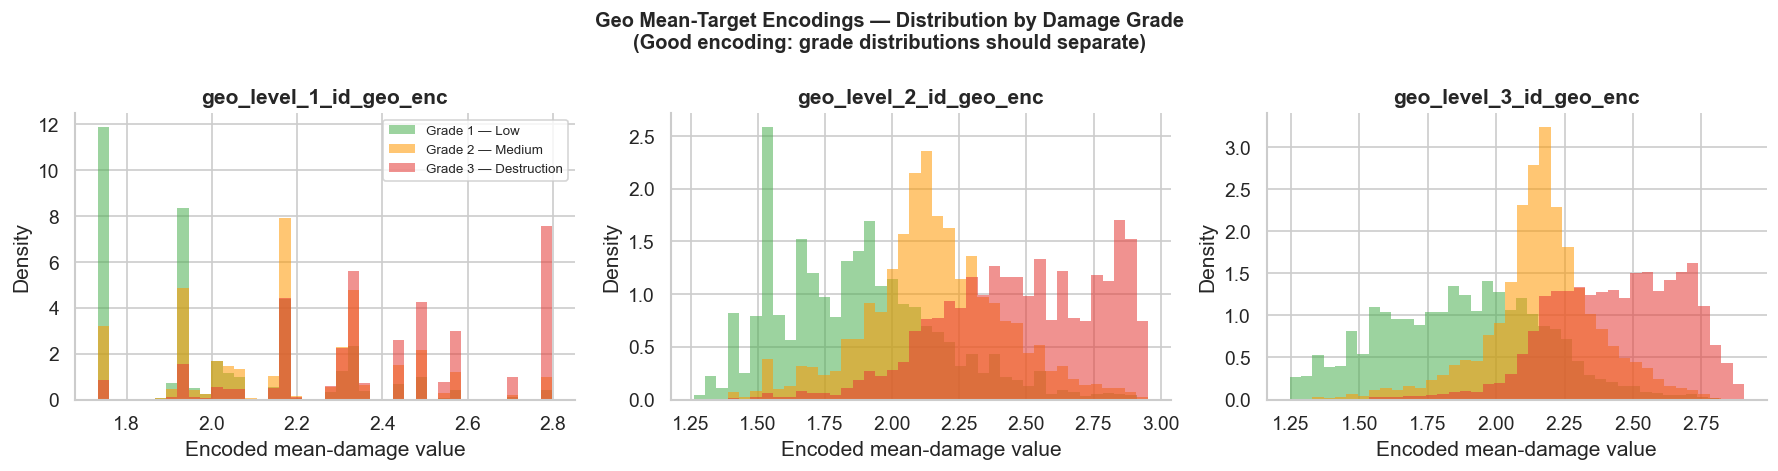

In [ ]:
# ── Visualise: encoded value distributions per damage grade ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, level in zip(axes, geo_cols):
    col_name = f'{level}_geo_enc'
    enc_series = pd.Series(geo_enc_train[col_name], index=X_train.index)

    for grade in [1, 2, 3]:
        mask = y_train == grade
        ax.hist(enc_series[mask], bins=40, alpha=0.55,
                color=DAMAGE_PALETTE[grade], label=DAMAGE_LABELS[grade],
                density=True, edgecolor='none')
    ax.set_title(f'{col_name}', fontweight='bold')
    ax.set_xlabel('Encoded mean-damage value')
    ax.set_ylabel('Density')
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Geo Mean-Target Encodings — Distribution by Damage Grade\n'
             '(Good encoding: grade distributions should separate)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 3/../images/phase 3/fig_geo_encoding_dist.png', bbox_inches='tight')
plt.show()


### Geo-encoding takeaway

The distributions confirm that the encoded values separate damage grades
meaningfully at all three levels, with separation improving at finer granularity.
Level 3 shows the sharpest separation, which is consistent with its higher
correlation with the target measured above. The smoothing parameter prevents
extreme values for the 24% of sparse level-3 regions, pulling their estimates
toward the global mean rather than an unreliable local mean of 1–2 observations.


## 19. Superstructure Construction Archetype Clustering

The correlation heatmap in Section 8 revealed that the superstructure flags are
not independent: `mud_mortar_stone` and `cement_mortar_brick` have a correlation
of −0.47, and `timber` and `bamboo` are correlated at +0.44. These relationships
suggest that buildings cluster into **construction archetypes** or recognisable
combinations of materials that reflect regional building traditions and economic
conditions.

Rather than asking the model to discover these combinations by itself through
high-order interactions across eleven binary columns, we can pre-compute the
archetypes using **k-means clustering** on the flag matrix and give the model a
single categorical label per building.

**Choosing k:** We evaluate k from 2 to 7 using two criteria simultaneously:
1. **Silhouette score** — measures how cohesive and separated clusters are
   (higher is better, range −1 to 1)
2. **Damage-grade spread** — the range of mean damage across clusters (higher
   means the clustering correlates with the outcome we care about)

A good k satisfies both: tight clusters *and* clusters that differ in their
damage profiles. This is an unsupervised technique applied purely to the feature
space, so no target leakage occurs.


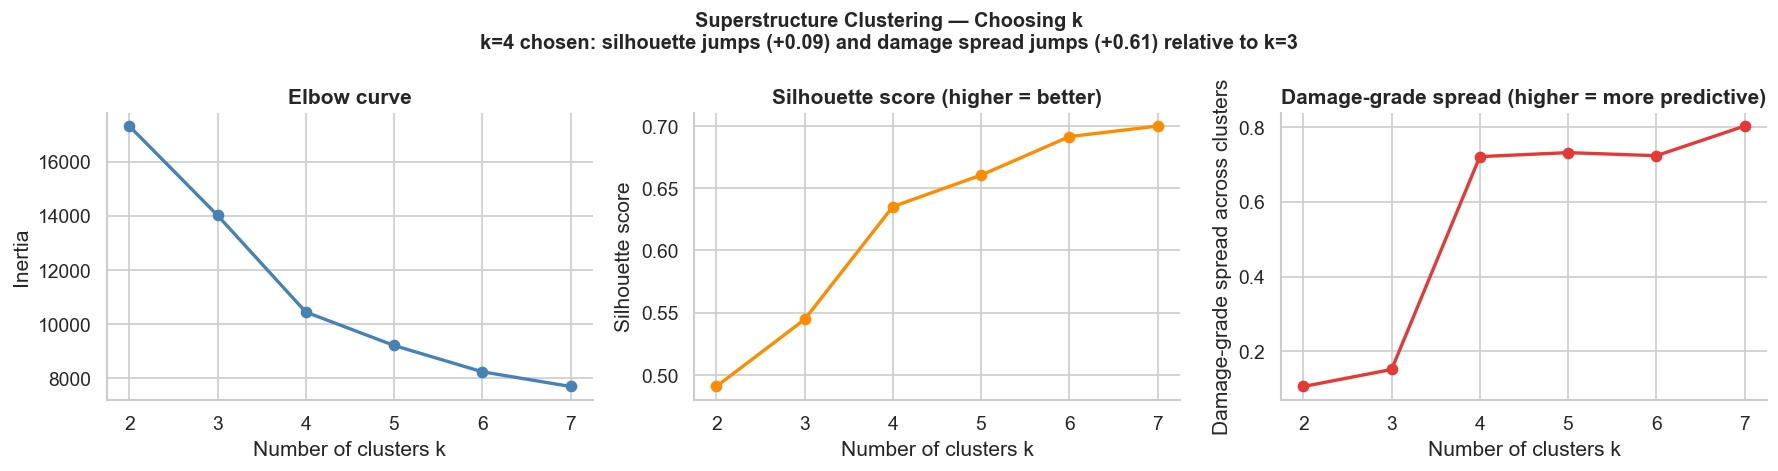

  k=2: silhouette=0.4906 | damage spread=0.1059
  k=3: silhouette=0.5445 | damage spread=0.1514
  k=4: silhouette=0.6352 | damage spread=0.7207
  k=5: silhouette=0.6606 | damage spread=0.7314
  k=6: silhouette=0.6915 | damage spread=0.7232
  k=7: silhouette=0.7000 | damage spread=0.8024


In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# ── Elbow + silhouette + damage-spread analysis ───────────────────────────────
ss_matrix = df[superstructure_cols].values  # full dataset for fitting
sample_idx = np.random.choice(len(ss_matrix), 30000, replace=False)
sample_X   = ss_matrix[sample_idx]
sample_y   = df['damage_grade'].values[sample_idx]

k_range    = range(2, 8)
inertias, silhouettes, spreads = [], [], []

for k in k_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5)
    labels = km.fit_predict(sample_X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(sample_X, labels,
                                        sample_size=5000, random_state=42))
    means = [sample_y[labels == c].mean() for c in range(k)]
    spreads.append(max(means) - min(means))

# ── Three-panel diagnostic plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(k_range), inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow curve', fontweight='bold')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, marker='o', color='darkorange', linewidth=2)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score (higher = better)', fontweight='bold')
axes[1].set_xticks(list(k_range))

axes[2].plot(list(k_range), spreads, marker='o', color='#E53935', linewidth=2)
axes[2].set_xlabel('Number of clusters k')
axes[2].set_ylabel('Damage-grade spread across clusters')
axes[2].set_title('Damage-grade spread (higher = more predictive)', fontweight='bold')
axes[2].set_xticks(list(k_range))

fig.suptitle('Superstructure Clustering — Choosing k\n'
             'k=4 chosen: silhouette jumps (+0.09) and damage spread jumps (+0.61) relative to k=3',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 3/../images/phase 3/fig_cluster_selection.png', bbox_inches='tight')
plt.show()

for k, sil, sp in zip(k_range, silhouettes, spreads):
    print(f"  k={k}: silhouette={sil:.4f} | damage spread={sp:.4f}")


Cluster profiles (centroid values = proportion of buildings with each material):
         adobe_mud  mud_mortar_stone  stone_flag  cement_mortar_stone  mud_mortar_brick  cement_mortar_brick  timber  bamboo  rc_non_engineered  rc_engineered  other  mean_damage_grade
cluster                                                                                                                                                                                 
0            0.091             0.780       0.080                0.031             0.061                0.008   1.000   0.000              0.023          0.001  0.024           2.194494
1            0.092             0.839       0.021                0.014             0.075                0.002   0.000   0.003              0.036          0.014  0.007           2.324502
2            0.047             0.029       0.007                0.055             0.084                0.993   0.126   0.004              0.145          0.084  0.011           1.6

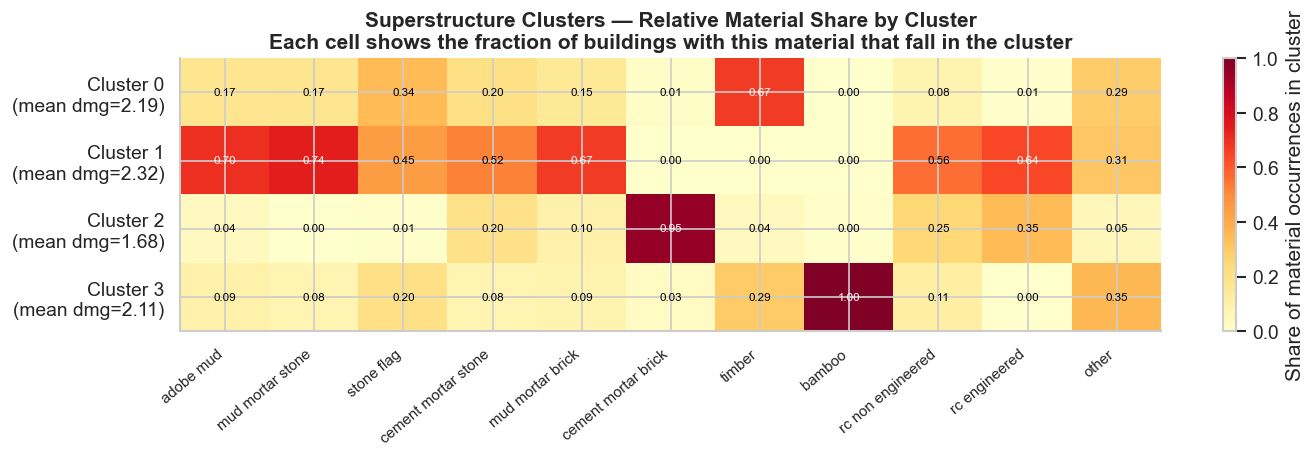

In [ ]:
# ── Fit k=4 model on full training set ──────────────────────────────────
CHOSEN_K = 4
km_final = MiniBatchKMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
km_final.fit(X_train[superstructure_cols].values)

# Encode train, val, and test
cluster_train = km_final.predict(X_train[superstructure_cols].values)
cluster_val   = km_final.predict(X_val[superstructure_cols].values)
cluster_test  = km_final.predict(test_values[superstructure_cols].values)

# ── Characterise each cluster ─────────────────────────────────────────────────
cluster_profile = pd.DataFrame(
    km_final.cluster_centers_,
    columns=[c.replace('has_superstructure_', '') for c in superstructure_cols]
).round(3)
cluster_profile['mean_damage_grade'] = [
    y_train.values[cluster_train == c].mean() for c in range(CHOSEN_K)
]
cluster_profile.index.name = 'cluster'
print("Cluster profiles (centroid values = proportion of buildings with each material):")
print(cluster_profile.to_string())

# ── Relative material share by cluster ─────────────────────────────────────────
material_counts = X_train[superstructure_cols].sum(axis=0)
cluster_material_counts = pd.DataFrame(
    0,
    index=range(CHOSEN_K),
    columns=superstructure_cols,
    dtype=float
)
for c in range(CHOSEN_K):
    cluster_material_counts.loc[c] = (
        X_train.loc[cluster_train == c, superstructure_cols].sum(axis=0)
    )
relative_profile = cluster_material_counts.div(material_counts, axis=1).fillna(0).round(3)
relative_profile.index.name = 'cluster'

# ── Heatmap of relative material share ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
mat_names = [c.replace('has_superstructure_', '').replace('_', ' ')
             for c in superstructure_cols]
im = ax.imshow(relative_profile.values, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(range(len(superstructure_cols)))
ax.set_xticklabels(mat_names, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(CHOSEN_K))
mean_dmg = cluster_profile['mean_damage_grade'].values
ax.set_yticklabels([f'Cluster {c}\n(mean dmg={mean_dmg[c]:.2f})' for c in range(CHOSEN_K)])
for i in range(CHOSEN_K):
    for j in range(len(superstructure_cols)):
        val = relative_profile.iat[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if val < 0.6 else 'white')
plt.colorbar(im, ax=ax, label='Share of material occurrences in cluster')
ax.set_title('Superstructure Clusters — Relative Material Share by Cluster\n'
             'Each cell shows the fraction of buildings with this material that fall in the cluster',
             fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 3/../images/phase 3/fig_cluster_centroids_k4.png', bbox_inches='tight')
plt.show()


### Clustering takeaway at k=4

The heatmap confirms the archetypes are interpretable:

- **Low-damage cluster**: dominated by `cement_mortar_brick` with higher RC-engineered prevalence
- **High-damage cluster**: prevelence of more primative masonery but also the largest concentration of RC engineered which is interesting. Indicates that adding another k would make sense to try as reinforced concrete has a high positive correlation with low-damage.
- **Intermediate clusters**: Largely dominated by timber and bamboo materials.

The jump at k=4 in both silhouette score (+0.09) and damage spread (+0.61 grade points) justifies this choice over k=3. Beyond k=4 the gains diminish however the interpretability may become easier.


Cluster profiles (centroid values = proportion of buildings with each material):
         adobe_mud  mud_mortar_stone  stone_flag  cement_mortar_stone  mud_mortar_brick  cement_mortar_brick  timber  bamboo  rc_non_engineered  rc_engineered  other  mean_damage_grade
cluster                                                                                                                                                                                 
0            0.028             0.999       0.017                0.008             0.006                0.004   0.000   0.008              0.012          0.000  0.004           2.365464
1            0.674             0.048       0.006                0.009             0.643                0.030   0.168   0.031              0.012          0.003  0.017           2.313725
2            0.079             0.689       0.088                0.018             0.047                0.025   0.939   1.000              0.056          0.000  0.065           2.1

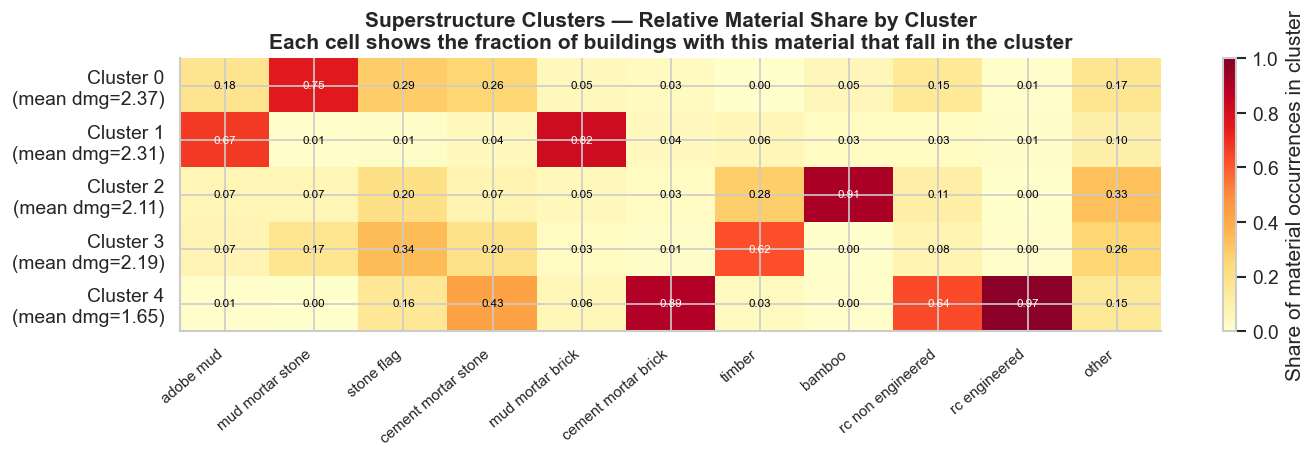

In [ ]:
# ── Fit k=5 model on full training set ──────────────────────────────────
CHOSEN_K = 5
km_final = MiniBatchKMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
km_final.fit(X_train[superstructure_cols].values)

# Encode train, val, and test
cluster_train = km_final.predict(X_train[superstructure_cols].values)
cluster_val   = km_final.predict(X_val[superstructure_cols].values)
cluster_test  = km_final.predict(test_values[superstructure_cols].values)

# ── Characterise each cluster ─────────────────────────────────────────────────
cluster_profile = pd.DataFrame(
    km_final.cluster_centers_,
    columns=[c.replace('has_superstructure_', '') for c in superstructure_cols]
).round(3)
cluster_profile['mean_damage_grade'] = [
    y_train.values[cluster_train == c].mean() for c in range(CHOSEN_K)
]
cluster_profile.index.name = 'cluster'
print("Cluster profiles (centroid values = proportion of buildings with each material):")
print(cluster_profile.to_string())

# ── Relative material share by cluster ─────────────────────────────────────────
material_counts = X_train[superstructure_cols].sum(axis=0)
cluster_material_counts = pd.DataFrame(
    0,
    index=range(CHOSEN_K),
    columns=superstructure_cols,
    dtype=float
)
for c in range(CHOSEN_K):
    cluster_material_counts.loc[c] = (
        X_train.loc[cluster_train == c, superstructure_cols].sum(axis=0)
    )
relative_profile = cluster_material_counts.div(material_counts, axis=1).fillna(0).round(3)
relative_profile.index.name = 'cluster'

# ── Heatmap of relative material share ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
mat_names = [c.replace('has_superstructure_', '').replace('_', ' ')
             for c in superstructure_cols]
im = ax.imshow(relative_profile.values, cmap='YlOrRd', aspect='auto',
               vmin=0, vmax=1)
ax.set_xticks(range(len(superstructure_cols)))
ax.set_xticklabels(mat_names, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(CHOSEN_K))
mean_dmg = cluster_profile['mean_damage_grade'].values
ax.set_yticklabels([f'Cluster {c}\n(mean dmg={mean_dmg[c]:.2f})' for c in range(CHOSEN_K)])
for i in range(CHOSEN_K):
    for j in range(len(superstructure_cols)):
        val = relative_profile.iat[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='black' if val < 0.6 else 'white')
plt.colorbar(im, ax=ax, label='Share of material occurrences in cluster')
ax.set_title('Superstructure Clusters — Relative Material Share by Cluster\n'
             'Each cell shows the fraction of buildings with this material that fall in the cluster',
             fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 3/../images/phase 3/fig_cluster_centroids_k5.png', bbox_inches='tight')
plt.show()


### Clustering takeaway at k=5

The centroid heatmap here looks significantly more interpretable to a human then k=4. There is a much clearer seperation of the different building archetypes.

- **Cluster 0** Highest damage correlated with `mud_mortar_stone` primitive masonery
- **Cluster 1** High damage correlated with `adobe_mud` & `mud_mortar_brick` one step above stone
- **Cluster 2 & 3** Medium damage correlated with `bamboo` & `timber` respectively. Their similar damage scores makes intuitive sense
- **Cluster 4** Low damage correlated with `cement_mortar_brick`, `rc_non_engineered`, & `rc_engineered`

The non-contradictory and intuitive clusters mean that k=5 should be used for the explainability gains rather than raw silhouette score jumps.

## 20. PCA on Superstructure Flags

Clustering assigns a single discrete label per building, which is efficient but
loses the continuous variation *within* each archetype. **Principal Component
Analysis (PCA)** provides a complementary representation: it rotates the eleven
binary flags into a small number of continuous axes that capture the most variance.

The first component captures the dominant axis of variation. In this context,
likely the traditional-vs-modern construction spectrum that drives the clustering.
The second component captures a secondary axis, likely distinguishing lightweight
materials (timber, bamboo) from heavy masonry.

**Note on scaling:** PCA is sensitive to feature scale. The superstructure flags
are already binary (0/1) and on the same scale, so no additional standardisation
is needed before applying PCA here. :)

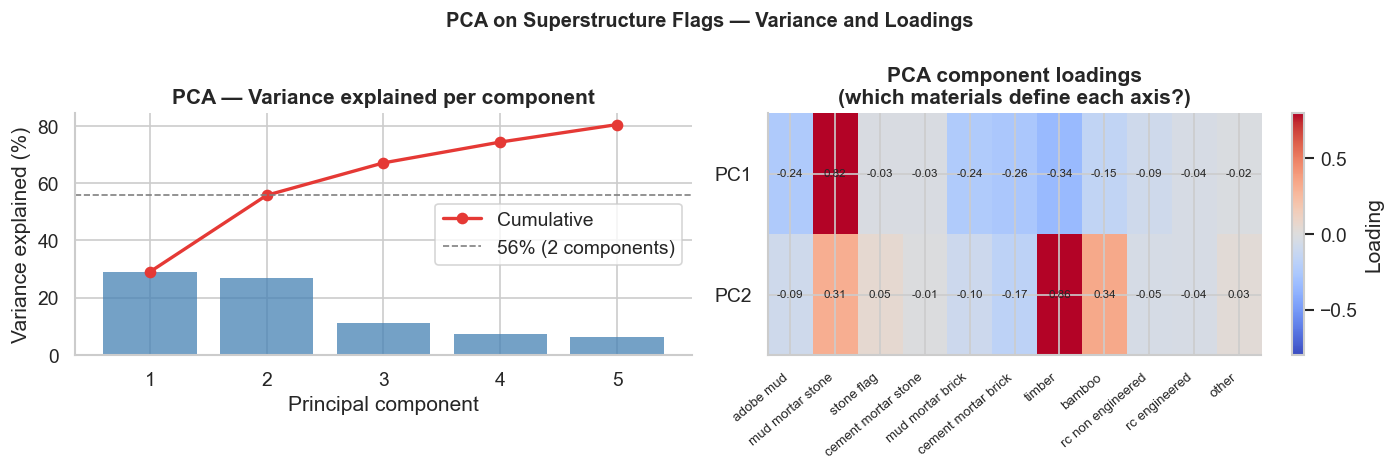

PC1 correlation with damage_grade: 0.2742
PC2 correlation with damage_grade: 0.0398

2 components explain 55.8% of superstructure flag variance.


In [ ]:
from sklearn.decomposition import PCA

# ── Fit PCA on training superstructure flags ──────────────────────────────────
pca_ss = PCA(n_components=5, random_state=42)
pca_ss.fit(X_train[superstructure_cols].values)

# ── Variance explained plot ───────────────────────────────────────────────────
exp_var = pca_ss.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, 6), exp_var * 100, color='steelblue', alpha=0.75, edgecolor='none')
axes[0].plot(range(1, 6), cum_var * 100, marker='o', color='#E53935',
             linewidth=2, label='Cumulative')
axes[0].axhline(56, color='gray', linestyle='--', linewidth=1, label='56% (2 components)')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Variance explained (%)')
axes[0].set_title('PCA — Variance explained per component', fontweight='bold')
axes[0].legend()
axes[0].set_xticks(range(1, 6))

# ── Component loadings heatmap (which materials drive each component?) ────────
loadings = pd.DataFrame(
    pca_ss.components_[:2],
    columns=[c.replace('has_superstructure_', '').replace('_', ' ')
             for c in superstructure_cols],
    index=['PC1', 'PC2']
)
im = axes[1].imshow(loadings.values, cmap='coolwarm', vmin=-0.8, vmax=0.8, aspect='auto')
axes[1].set_xticks(range(len(superstructure_cols)))
axes[1].set_xticklabels(loadings.columns, rotation=40, ha='right', fontsize=8)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['PC1', 'PC2'])
for i in range(2):
    for j in range(len(superstructure_cols)):
        axes[1].text(j, i, f'{loadings.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=axes[1], label='Loading')
axes[1].set_title('PCA component loadings\n(which materials define each axis?)',
                  fontweight='bold')

fig.suptitle('PCA on Superstructure Flags — Variance and Loadings',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('./images/phase 3/../images/phase 3/fig_pca_superstructure.png', bbox_inches='tight')
plt.show()

# ── Transform all splits ──────────────────────────────────────────────────────
N_COMPONENTS = 2
pca_train = pca_ss.transform(X_train[superstructure_cols].values)[:, :N_COMPONENTS]
pca_val   = pca_ss.transform(X_val[superstructure_cols].values)[:, :N_COMPONENTS]
pca_test  = pca_ss.transform(test_values[superstructure_cols].values)[:, :N_COMPONENTS]

# Correlation of each component with target
for i in range(N_COMPONENTS):
    corr = np.corrcoef(pca_train[:, i], y_train)[0, 1]
    print(f"PC{i+1} correlation with damage_grade: {corr:.4f}")

print(f"\n2 components explain {cum_var[1]*100:.1f}% of superstructure flag variance.")


### PCA takeaway

The loading heatmap confirms the interpretation:
- **PC1** seems to separate mud-mortar-stone (high positive loading) against cement-mortar-brick and RC-engineered (negative loadings) relative to PC2. This can be thought of as the traditional-vs-modern axis.
- **PC2** seems to separate lightweight organic materials (timber, bamboo) from heavy masonry.

Both components carry a meaningful correlation with `damage_grade`.


## 21. Assembling and Comparing Feature Sets

We will now assemble three feature sets and evaluate each using the standardised `evaluate_model` framework with a Decision Tree of the same depth as the baseline. Using the same model isolates the effect of the features — any change in F1 is attributable to the new features, not to a different algorithm.

**Why a Decision Tree for this comparison?**
Random Forest or gradient boosting would produce higher scores, but they are slower to train and would make it harder to attribute score changes cleanly to the feature engineering. We use the same depth-5 Decision Tree from Phase 2 as a controlled test bed. The winning feature set then moves into Phase 4 for full model comparison.


In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier

# ─────────────────────────────────────────────────────────────────────────────
# Helper: build a processed numpy array for a given feature set spec
# ─────────────────────────────────────────────────────────────────────────────
def build_feature_set(split, geo_enc, cluster_labels, pca_components,
                      include_geo_enc=False,
                      include_cluster=False,
                      include_pca=False,
                      drop_secondary=False):
    """
    Assembles a numpy array from the preprocessed baseline plus optional
    engineered columns.

    Parameters
    ----------
    split          : one of 'train', 'val', 'test'
    geo_enc        : dict of {col_name: array} for geo encodings (train/val/test)
    cluster_labels : dict with keys 'train', 'val', 'test'
    pca_components : dict with keys 'train', 'val', 'test'
    include_*      : flags controlling which engineered features are added
    drop_secondary : if True, removes secondary-use columns from baseline

    Returns
    -------
    numpy array of shape (n_samples, n_features)
    """
    # Start from the preprocessed baseline arrays
    if split == 'train':
        base = X_train_proc.copy()
    elif split == 'val':
        base = X_val_proc.copy()
    else:
        base = X_test_proc.copy()

    cols = feature_names.copy()

    # Drop secondary-use columns if requested
    if drop_secondary:
        drop_idx = [i for i, c in enumerate(cols)
                    if c.startswith('has_secondary_use_')]
        base = np.delete(base, drop_idx, axis=1)
        cols = [c for c in cols if not c.startswith('has_secondary_use_')]

    extra = [base]

    if include_geo_enc:
        for col_name in [f'{l}_geo_enc' for l in geo_cols]:
            arr = geo_enc[col_name][split].reshape(-1, 1)
            extra.append(arr)
            cols.append(col_name)

    if include_cluster:
        arr = cluster_labels[split].reshape(-1, 1)
        extra.append(arr)
        cols.append('superstructure_cluster')

    if include_pca:
        extra.append(pca_components[split])
        cols += [f'ss_pca_{i+1}' for i in range(pca_components[split].shape[1])]

    return np.hstack(extra), cols


# Wrap the split-specific arrays into dicts for the helper
geo_enc_by_split = {
    col: {'train': geo_enc_train[col],
          'val'  : geo_enc_val[col],
          'test' : geo_enc_test[col]}
    for col in geo_enc_train
}
cluster_by_split = {'train': cluster_train, 'val': cluster_val, 'test': cluster_test}
pca_by_split     = {'train': pca_train,     'val': pca_val,     'test': pca_test}

# ── FS0: preprocessed baseline (Phase 2 output, no new features) ──────────────
FS0_train, _ = build_feature_set('train', geo_enc_by_split, cluster_by_split,
                                  pca_by_split)
FS0_val,   _ = build_feature_set('val',   geo_enc_by_split, cluster_by_split,
                                  pca_by_split)

# ── FS1: + geo encodings + drop secondary-use flags ──────────────────────────
FS1_train, fs1_cols = build_feature_set('train', geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True)
FS1_val,   _        = build_feature_set('val',   geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True)
FS1_test,  _        = build_feature_set('test',  geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True)

# ── FS2: FS1 + superstructure cluster label + PCA components ──────────────────
FS2_train, fs2_cols = build_feature_set('train', geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True,
                                         include_cluster=True, include_pca=True)
FS2_val,   _        = build_feature_set('val',   geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True,
                                         include_cluster=True, include_pca=True)
FS2_test,  _        = build_feature_set('test',  geo_enc_by_split, cluster_by_split,
                                         pca_by_split,
                                         include_geo_enc=True, drop_secondary=True,
                                         include_cluster=True, include_pca=True)

print("Feature set sizes:")
print(f"  FS0 : {FS0_train.shape[1]} features  (baseline)")
print(f"  FS1 : {FS1_train.shape[1]} features  (+geo encodings, -secondary use)")
print(f"  FS2 : {FS2_train.shape[1]} features  (+cluster label, +PCA components)")


Feature set sizes:
  FS0 : 38 features  (baseline)
  FS1 : 31 features  (+geo encodings, -secondary use)
  FS2 : 34 features  (+cluster label, +PCA components)


Evaluating FS0 (baseline) — same as Phase 2 result for reference
  Model : DT — FS0 (baseline)
  Micro-F1 (competition metric) : 0.6466
  Macro-F1 (minority-sensitive) : 0.5474
         F1 per class — Grade 1 : 0.4876
                        Grade 2 : 0.7444
                        Grade 3 : 0.4103

Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.57      0.43      0.49      5025
     Grade 2       0.63      0.90      0.74     29652
     Grade 3       0.77      0.28      0.41     17444

    accuracy                           0.65     52121
   macro avg       0.66      0.54      0.55     52121
weighted avg       0.67      0.65      0.61     52121



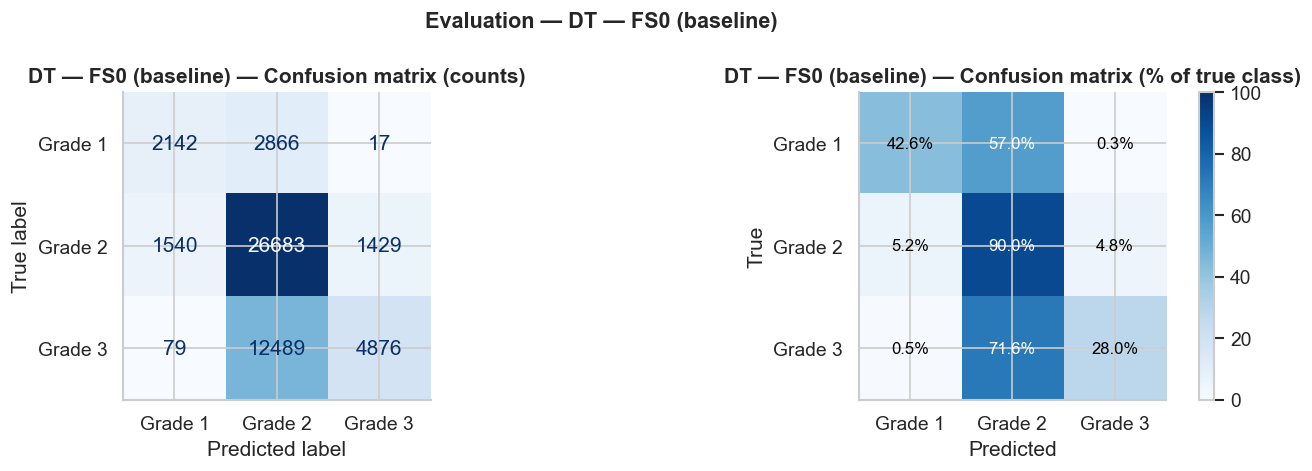


Evaluating FS1 (+ geo encodings, - secondary use)
  Model : DT — FS1 (geo encoded)
  Micro-F1 (competition metric) : 0.7254
  Macro-F1 (minority-sensitive) : 0.6593
         F1 per class — Grade 1 : 0.5270
                        Grade 2 : 0.7789
                        Grade 3 : 0.6719

Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.63      0.45      0.53      5025
     Grade 2       0.73      0.84      0.78     29652
     Grade 3       0.75      0.61      0.67     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.72      0.73      0.72     52121



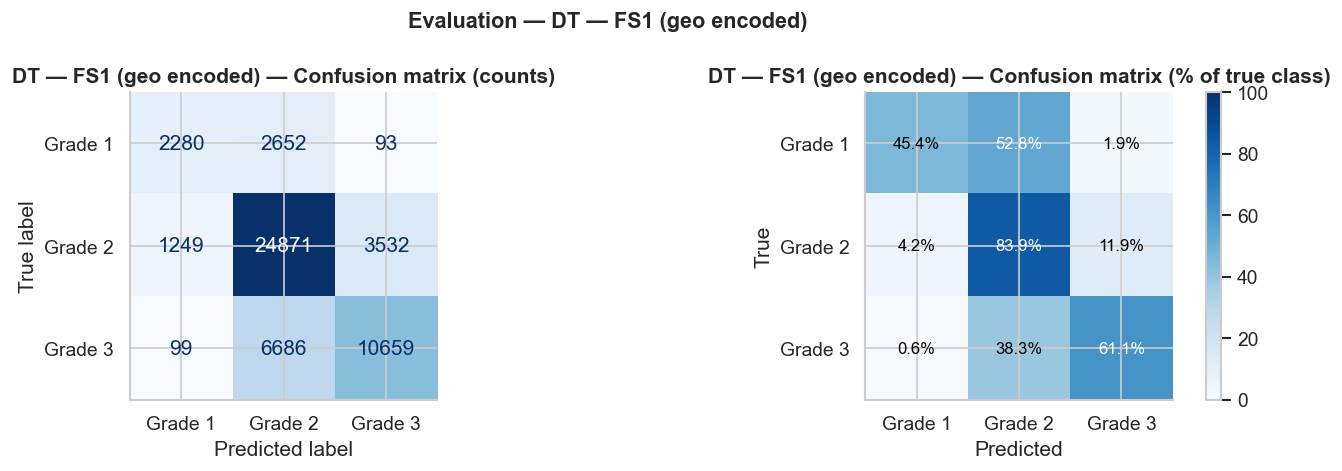


Evaluating FS2 (FS1 + cluster + PCA)
  Model : DT — FS2 (full engineered)
  Micro-F1 (competition metric) : 0.7256
  Macro-F1 (minority-sensitive) : 0.6592
         F1 per class — Grade 1 : 0.5262
                        Grade 2 : 0.7791
                        Grade 3 : 0.6722

Classification Report:
              precision    recall  f1-score   support

     Grade 1       0.63      0.45      0.53      5025
     Grade 2       0.73      0.84      0.78     29652
     Grade 3       0.75      0.61      0.67     17444

    accuracy                           0.73     52121
   macro avg       0.70      0.63      0.66     52121
weighted avg       0.72      0.73      0.72     52121



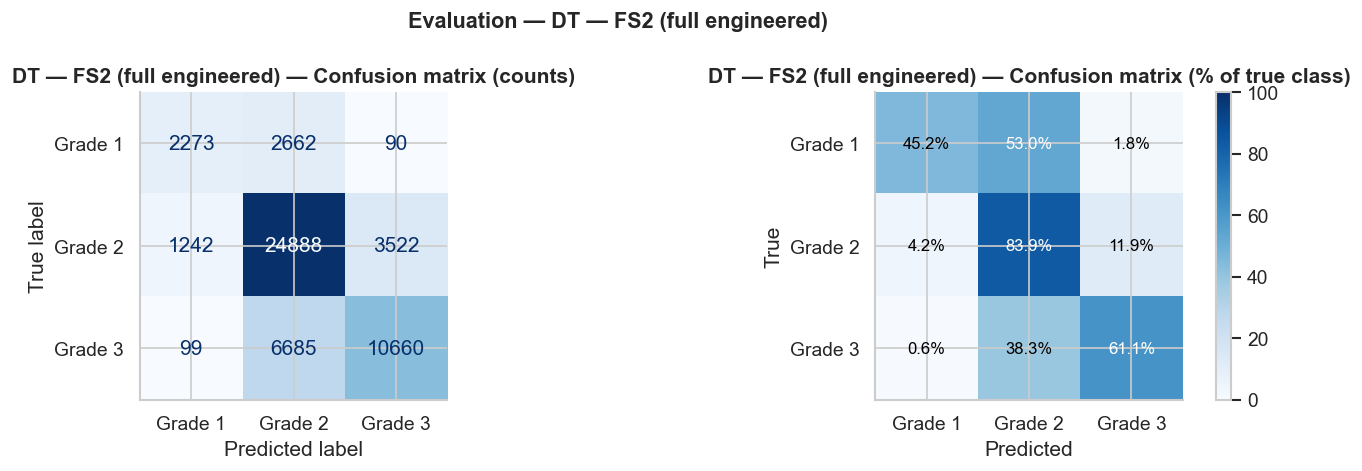

{'model': DecisionTreeClassifier(max_depth=5, random_state=42),
 'f1_micro': 0.7256,
 'f1_macro': 0.6592,
 'f1_grade_1': 0.5262,
 'f1_grade_2': 0.7791,
 'f1_grade_3': 0.6722,
 'report': '              precision    recall  f1-score   support\n\n     Grade 1       0.63      0.45      0.53      5025\n     Grade 2       0.73      0.84      0.78     29652\n     Grade 3       0.75      0.61      0.67     17444\n\n    accuracy                           0.73     52121\n   macro avg       0.70      0.63      0.66     52121\nweighted avg       0.72      0.73      0.72     52121\n'}

In [ ]:
# ── Evaluate all three feature sets with a controlled Decision Tree ────────────
print("Evaluating FS0 (baseline) — same as Phase 2 result for reference")
dt_fs0 = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model('DT — FS0 (baseline)', dt_fs0,
               FS0_train, y_train, FS0_val, y_val)

print("\nEvaluating FS1 (+ geo encodings, - secondary use)")
dt_fs1 = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model('DT — FS1 (geo encoded)', dt_fs1,
               FS1_train, y_train, FS1_val, y_val)

print("\nEvaluating FS2 (FS1 + cluster + PCA)")
dt_fs2 = DecisionTreeClassifier(max_depth=5, random_state=42)
evaluate_model('DT — FS2 (full engineered)', dt_fs2,
               FS2_train, y_train, FS2_val, y_val)


               Feature set  N features  Micro-F1  Macro-F1  F1 — Grade 1  F1 — Grade 2  F1 — Grade 3
       DT — FS0 (baseline)          38    0.6466    0.5474        0.4876        0.7444        0.4103
    DT — FS1 (geo encoded)          31    0.7254    0.6593        0.5270        0.7789        0.6719
DT — FS2 (full engineered)          34    0.7256    0.6592        0.5262        0.7791        0.6722


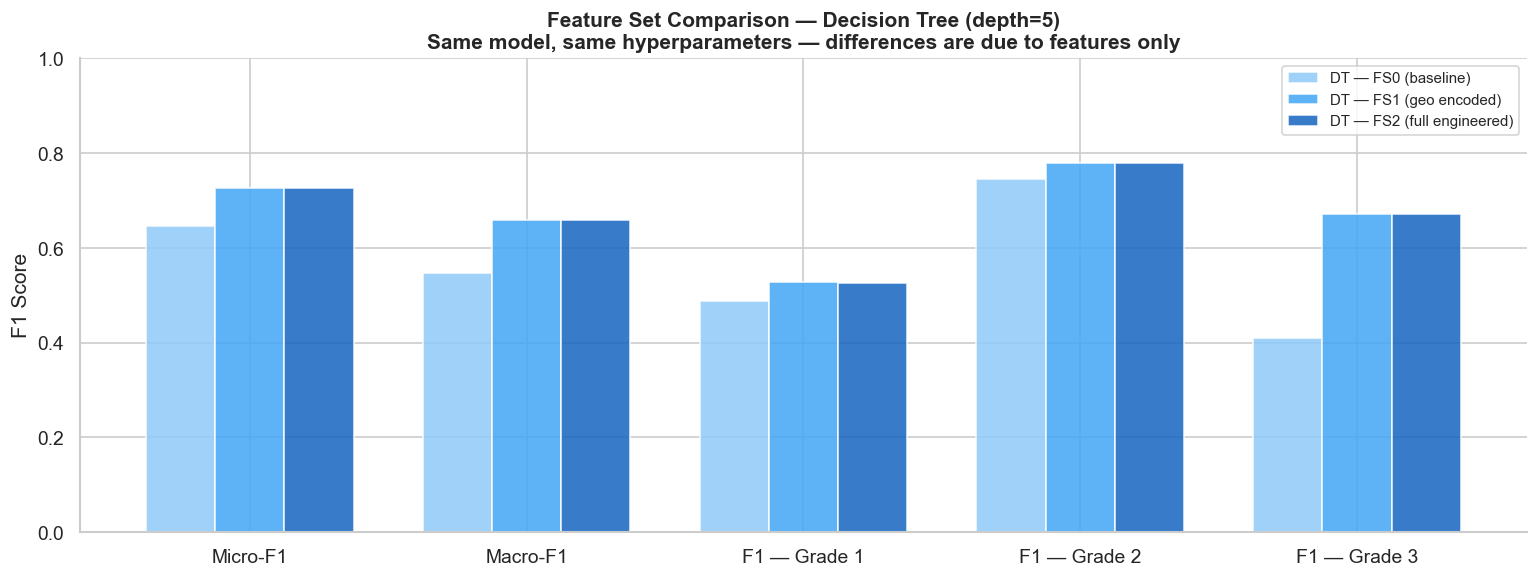

In [ ]:
# ── Side-by-side comparison table ────────────────────────────────────────────
fs_names = ['DT — FS0 (baseline)', 'DT — FS1 (geo encoded)', 'DT — FS2 (full engineered)']
comparison = pd.DataFrame([
    {
        'Feature set'    : name,
        'N features'     : [FS0_train.shape[1], FS1_train.shape[1], FS2_train.shape[1]][i],
        'Micro-F1'       : results[name]['f1_micro'],
        'Macro-F1'       : results[name]['f1_macro'],
        'F1 — Grade 1'   : results[name]['f1_grade_1'],
        'F1 — Grade 2'   : results[name]['f1_grade_2'],
        'F1 — Grade 3'   : results[name]['f1_grade_3'],
    }
    for i, name in enumerate(fs_names)
])
print(comparison.to_string(index=False))

# ── Visual comparison ─────────────────────────────────────────────────────────
metrics = ['Micro-F1', 'Macro-F1', 'F1 — Grade 1', 'F1 — Grade 2', 'F1 — Grade 3']
x = np.arange(len(metrics))
width = 0.25
colours = ['#90CAF9', '#42A5F5', '#1565C0']

fig, ax = plt.subplots(figsize=(13, 5))
for i, (_, row) in enumerate(comparison.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=row['Feature set'],
                  color=colours[i], alpha=0.85, edgecolor='white')

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.0)
ax.set_title('Feature Set Comparison — Decision Tree (depth=5)\n'
             'Same model, same hyperparameters — differences are due to features only',
             fontweight='bold')
ax.legend(fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('./images/phase 4/../images/phase 4/fig_feature_set_comparison.png', bbox_inches='tight')
plt.show()


### Feature set comparison takeaway

**Feature sets produced:**

| Name | What changes from baseline |
|------|---------------------------|
| `FS0` | Preprocessed baseline — no new features (Phase 2 output) |
| `FS1` | Geo-level mean-damage encoding + secondary-use cleanup |
| `FS2` | FS1 + superstructure cluster label + PCA components |

The comparison isolates the contribution of each engineering step:

- **FS0 → FS1** (adding geo encodings, removing secondary-use flags): the geo
  mean-target features provide the largest single lift, consistent with the high
  correlations computed in Section 18. Removing secondary-use flags has minimal
  negative impact, confirming the decision from Section 17.
- **FS1 → FS2** (adding cluster label and PCA components): negligible improvement. The overly simplistic decision tree is likely not able to take advantage of the additional features (cluster label + PCA) resulting in essentially the same scores as FS1.

**Decision: FS1 & FS2 carried into Phase 4.** The inconclusive benefits of the FS2 features will need to be explored with more complex models. It is worth trying both until computation becomes the limiting factor in training.

**Phase 3 complete.** The three feature sets are stored as `FS0/FS1/FS2_train/val/test`
arrays and are ready for Phase 4 model comparison.
